> ### STATUS - annotated 2026-08-12 by agent `nb-banner-1217`. Nothing below this banner was rewritten.
>
> ### The parameters on this page are NOT the adopted ones.
>
> **What this notebook decided.** Two pre-registered forcing cells - **H1** (v1 forcing, new
> objective) and **H2** (v2 forcing, new objective) - sharing engine, split, algorithm and two
> seeds, with **H2 - H1** as the deliverable.
>
> **What happened to it.** H2 - H1 stands as a *finding* (the repair moved volume and left
> correlation untouched; `docs/26`). **The H1-vs-H2 comparison itself did not survive**: the
> seed expansion re-ran both cells at six seeds each and read them out as **NOT SEPARATED** -
> gap **0.00915** against a maximum within-cell seed spread of **0.05082** (`docs/29` Rule (a)).
> And both cells here rail parameters, which the rule written before the run calls a failure:
> `docs/26` §5.1 - *"Anyone reading H2's numbers as a clean result is reading them wrong."*
>
> **What was adopted instead.** **H2E** = v2 forcing + this notebook's revised objective +
> **FAO-56 threshold ET, theta_crit 0.6** - a cell that did not exist when this notebook ran.
> It passed all three of its pre-registered conditions (`docs/29` Rule (b)), best seed
> **20260901**, objective **F = 0.25931**, and stage C0 froze it into `parameters_H2E.csv`,
> `q_gauge_H2E.npz` and `report_H2E.json` (`docs/26` Addendum, 2026-08-10).
>
> **The caveat that must travel with the adopted fit.** El Nino **skill over climatology is
> -0.0005**: in the adopted configuration the dry phase sits **at** climatology, not above it
> (`docs/26` Addendum A.5(b)).
>
> **Where the current state lives.** `docs/26` + its 2026-08-10 Addendum - the parameter record;
> **read §5.1 before quoting any fitted parameter** · `docs/29` (the read-out) · `docs/30` §1
> (why Phase B closed: by decision, at a measured input ceiling). Section 12.2's *"only
> remaining untried lever"*, the CHIRPS-gauge merge, was subsequently **built, validated and NOT
> adopted** (`docs/18` §15) and refuted again as **H-CHIRPS** on its **+7.5 %** volume gate
> (`docs/33`), so the forcing is still **v2, gauge-only**; a merged **v3** does not exist.
>
> **Addendum 2026-08-19 - this page is a RECORD, and re-executing it is not free.** Measured
> today: `src/mgb_hydrology.py` is sha256 **93b180a9113f5946** and `src/calib_v2.py` is
> **30ab13a630278d5d**, against the **cdea026afe796f6d** and **3342728f2a38bac1** recorded in the
> executed output below - the engine moved with `80a7c10` (the FAO-56 threshold ET that H2E is
> built on) and the search code with `19dce32` (the C2b peak term). Section 0.1's cell asserts
> `ENG_SHA == V1['engine']['sha256']`, so a re-execution **stops there** - which is the guard
> working, not a bug: on today's engine H1 would no longer isolate the objective. Read every number
> below as the record of the run that produced it. The second consequence, a destructive overwrite,
> is at **§13**; and the final state of §12.2's *"only untried lever"* - the last route measured
> and bounded at **Δr = +0.0058**, r 0.57 -> ~0.576 (`docs/58`) - is read out at **§12.2**.

# Notebook 14 - refit under a revised objective, on two pre-registered forcing cells

**What this run is for.** The previous calibration (Config B, v1 forcing, v1 objective) reached a
validation median KGE of 0.29 and then failed in exactly one place: the El Nino 2015-16 half of the
ENSO contrast the project exists to study. `docs/22` measured the failure to the end. All three
standing hypotheses were refuted, one was backwards, and two defects were left on the table:

1. **The search bought its fit with compensating errors.** `kc_mult` railed at 2.00, `k_int` railed
   at 117.4 d - *slower than* `k_bas` at 68.6 d, which inverts the stores - and `fint` sat at 4 % of
   its range starving the inverted store to partly undo the rail.
2. **The simulated low-flow recession was 3-4x too slow in every period**, and the objective could
   not see it: Morris put $\mu^*$ for `k_bas` at 0.044, rank 5 of 10, so the fitted 68.6 d was
   essentially the 60 d prior carried through. `k_bas`'s lower bound of 15 d also **excluded the
   observed 13.9 d**.

Separately, the rainfall forcing was rebuilt: `docs/18` s9-s12 found and repaired zero-suppression
in the DHIME gauge records, made the IDW deterministic, and triaged the energy-floor gauges. That is
a change to the *input*, not to the model.

**So there are two candidate causes and they must not be confounded.** This notebook runs them as
**pre-registered cells**, each with the same engine, the same split, the same algorithm and the same
two seeds:

| cell | forcing | objective | what it isolates |
|---|---|---|---|
| (reference) | v1 | old | Config B, already in hand - not re-run |
| **H1** | v1 | **new** | the objective change, alone |
| **H2** | **v2** | **new** | the forcing repair, alone (H2 - H1) |

**H2 minus H1 is the deliverable.** H3 (v2 + a CHIRPS-gauge merge) is **dropped**: the merge was
never implemented in notebook 11 - the areal mean is exactly the gauge-only figure and no
quantile-mapping output exists - so there is nothing to run. It is logged as the remaining open item
in section 12, and given the gauge-only leave-one-out daily $r$ of 0.429 it is now the only
untried lever on the dry phase.

> **RETIRED / superseded 2026-08-19 - shown, not quoted as current.** "The only untried lever" was
> true when written and is not true now. The merge was built (`src/merge_chirps_gauges.py`): its
> leave-one-out gate **passed** at $r$ **0.447** against the gauge-only **0.429**, and its volume
> gate **failed** at **2,188.5 mm/yr**, **+7.47 %** against the registered band
> **[2,016.0, 2,056.8]** - twice, because the registered repair (H-CHIRPS, `docs/33` §1) was run
> and was a **no-op**, with the diagnosed cause **wrong**. `docs/18` §15.5 is the owning read-out:
> *"no route to a passing volume gate exists inside the merge code."* The one surviving upstream
> route - the **139** stations still reporting rain-selectively, whose missing days are not in the
> record at all - was measured and bounded at **Δr = +0.0058**, a perfect-case ceiling of
> r 0.57 -> ~0.576 (`docs/58`). The ceiling is **structural**. No v3 forcing exists and none is
> pending. The full read-out is at §12.2.

**The expectation, written down before the numbers.** The repair fixed *volume*. Volume was never
what limited *correlation* (`docs/22` s4.7: $r$ stayed inside 0.556-0.572 across all twelve
parameter configurations tested). So the prediction is that H2 - H1 improves $\beta$ and PBIAS while
$r$ and the dry-phase ceiling hold. **If that is what happens it is a finding, not a failure**: it
confirms that volume and correlation are independent problems and that the remaining deficit is not
in the rainfall total.

**Working rules applied throughout.** Every choice states its reason and an alternative rejected;
every headline number is recomputed a second way; new code passes a synthetic test with an
analytically known answer before it touches basin data; no number appears here that this notebook
did not compute; and where a result looks good it is attacked.

## 0.1 - Prerequisites, and where the shared code lives

The search machinery is in **`src/calib_v2.py`**, not in this notebook, for two reasons that are not
tidiness. First, the four searches (2 cells x 2 seeds) run as **concurrent OS processes**, and a
worker entry point has to be importable. Second, the notebook's reporting code and the workers'
search code are then literally the same functions - if they drifted, the $F$ reported here would not
be the $F$ that was optimised.

| Prerequisite | What it provides | Checked below |
|---|---|---|
| `src/mgb_hydrology.py` | the engine, **unmodified** | sha256 recorded and compared with nb13's |
| `src/calib_v2.py` | bounds, objective, DDS, recession statistic, cell loader | sha256 recorded; smoke-tested in 0.3 |
| `data/processed/model_inputs/` | the **v1** bundle, 2009-2017 | array shapes vs its own manifest |
| `data/processed/model_inputs_v2/` | the **v2** bundle, 2008-2018 | array shapes vs its own manifest |
| `data/processed/sim_baseline/parameters.json` | nb13 v1 priors | priors re-derived here must match |
| `data/processed/sim_baseline_v2/balance.json` | nb13 v2 baseline fleet metrics | quoted, not recomputed |
| `data/processed/sim_calibrated/` | **Config B as adopted** - the reference cell | its stored flows are re-scored here |
| `data/processed/forcing_minibacia_precip.csv` | 2008 rainfall for the H1 warm-up | row count vs the file's own byte line count |

Nothing is improvised if one is missing: the notebook stops.

In [1]:
import json, pathlib, sys, time, hashlib, subprocess, warnings, os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
%matplotlib inline
plt.rcParams.update({'figure.dpi': 100, 'axes.grid': False, 'font.size': 9})

REPO = None
for b in [pathlib.Path.cwd()] + list(pathlib.Path.cwd().parents):
    if (b / 'src' / 'calib_v2.py').exists() and (b / 'data' / 'processed').exists():
        REPO = b
        break
if REPO is None:
    raise SystemExit('cannot locate the repository root')
PROC = REPO / 'data' / 'processed'
sys.path.insert(0, str(REPO / 'src'))

need = [PROC / 'model_inputs' / f for f in ('topology.npz', 'parameters.npz', 'forcing.npz',
                                            'discharge.npz', 'manifest.json')]
need += [PROC / 'model_inputs_v2' / f for f in ('topology.npz', 'parameters.npz', 'forcing.npz',
                                                'discharge.npz', 'manifest.json')]
need += [PROC / 'sim_baseline' / 'parameters.json',
         PROC / 'sim_baseline_v2' / 'balance.json',
         PROC / 'sim_calibrated' / 'calibration.json',
         PROC / 'sim_calibrated' / 'q_gauge.npz',
         PROC / 'forcing_minibacia_precip.csv',
         REPO / 'src' / 'mgb_hydrology.py', REPO / 'src' / 'calib_v2.py']
missing = [str(p) for p in need if not p.exists()]
if missing:
    raise SystemExit(f'PREREQUISITES MISSING, stopping rather than improvising: {missing}')

import mgb_hydrology as mgb
import calib_v2 as CV

ENG_SHA = hashlib.sha256((REPO / 'src' / 'mgb_hydrology.py').read_bytes()).hexdigest()
CAL_SHA = hashlib.sha256((REPO / 'src' / 'calib_v2.py').read_bytes()).hexdigest()
BASE_PJ = json.loads((PROC / 'sim_baseline' / 'parameters.json').read_text())
BASE13V2 = json.loads((PROC / 'sim_baseline_v2' / 'balance.json').read_text())
V1 = json.loads((PROC / 'sim_calibrated' / 'calibration.json').read_text())

print(f'repo         {REPO}')
print(f'engine       src/mgb_hydrology.py  sha256 {ENG_SHA[:16]}')
print(f'             nb13 v1 ran {BASE_PJ["engine"]["sha256"][:16]}  identical: '
      f'{ENG_SHA == BASE_PJ["engine"]["sha256"]}')
print(f'             v1 calibration ran {V1["engine"]["sha256"][:16]}  identical: '
      f'{ENG_SHA == V1["engine"]["sha256"]}')
print(f'search code  src/calib_v2.py       sha256 {CAL_SHA[:16]}')
assert ENG_SHA == V1['engine']['sha256'], (
    'the engine changed since the v1 calibration - H1 would not isolate the objective')
print(f'\nthe reference cell, as recorded by the v1 run:')
print(f'  adopted configuration {V1["adopted_configuration"]}, '
      f'{V1["regionalisation"]["free_parameters"][V1["adopted_configuration"]]} free parameters')
print(f'  F: prior {V1["algorithm"]["best_F"]["prior"]:.5f}, random null '
      f'{V1["algorithm"]["best_random_null_F"]:.5f}, Config A '
      f'{V1["algorithm"]["best_F"]["A"]:.5f}, Config B {V1["algorithm"]["best_F"]["B"]:.5f}')
print(f'  budget {V1["algorithm"]["budget_per_seed"]} per seed x '
      f'{V1["algorithm"]["seeds_per_config"]} seeds, {V1["algorithm"]["seconds_per_run"]:.2f} s/run,'
      f' {V1["algorithm"]["wall_minutes"]:.0f} min total')
F_REF = {'prior': V1['algorithm']['best_F']['prior'],
         'random null': V1['algorithm']['best_random_null_F'],
         'Config B': V1['algorithm']['best_F']['B'], 'perfect': 1.0}

repo         C:\dev\magdalena-mgb-sed
engine       src/mgb_hydrology.py  sha256 cdea026afe796f6d
             nb13 v1 ran cdea026afe796f6d  identical: True
             v1 calibration ran cdea026afe796f6d  identical: True
search code  src/calib_v2.py       sha256 3342728f2a38bac1

the reference cell, as recorded by the v1 run:
  adopted configuration B, 18 free parameters
  F: prior 0.12764, random null 0.17292, Config A 0.22596, Config B 0.24286
  budget {'A': 178, 'B': 209} per seed x 2 seeds, 5.73 s/run, 63 min total


## 0.2 - What is inherited, and therefore not re-litigated here

| Established elsewhere | Consequence for this notebook |
|---|---|
| nb13 v2: mass closes to $1.7\times10^{-17}$, the negative-$W$ guard never fired, three incompatible starts converge to 0.18 % of mean flow, numpy and numba routers agree to **exactly** zero | The engine is not re-verified. Mass is re-checked **at the fitted parameters** in section 8, because a new parameter set is a new test of the guards, not of the algebra. |
| nb14 v1: Morris $\mu^*$ ranking over the ten parameters; `k_sup`, `wm_mult`, `celerity` earn a macro-region; `adr` earns an IGAC soil-family split | The screening is **not re-run**. It is a property of the model and the gauge network, not of the objective being changed, and re-running it for two cells would spend ~15 % of the search budget reproducing a ranking already on record. The inherited choice is printed below so it is visible, not silent. |
| nb14 v1 s1: the engine cannot evaporate more than $\max(1,k_c)\,PET$, so a third of the fleet has an unreachable water balance and the outlet carries a PBIAS floor | Recomputed per cell in section 5, because the **v2 forcing changes the floor** - that is one of the things the repair was supposed to do. |
| `docs/22` s4.7: $r$ stayed in 0.556-0.572 across twelve parameter configurations | $r$ is not expected to move. A refit that does not move $r$ has not failed; a refit that *claims* to have moved it needs the permutation null in section 10. |
| `docs/23` s13.2: catchment areas are unreliable per gauge in **both** networks | No per-gauge specific yield in t/km2/yr is published anywhere in this notebook. |

The split is also inherited, and it is the reason the ENSO result is a prediction rather than a fit:
**calibrate on 2012-2014 only** (the three consecutive ENSO-neutral years), warm up the search
segment on 2011, and validate on everything else - La Nina 2011, El Nino 2015-16, the remaining
neutral years, and (in H2 only) 2018. Klemes (1986)'s differential split-sample test. Putting either
ENSO extreme in calibration would make the project's headline result circular.

In [2]:
print(f'inherited from the v1 Morris screening (NOT re-derived here):')
print(f'  calibrated   {V1["screening"]["calibrated"]}')
print(f'  frozen       {V1["screening"]["frozen"] or "none"}')
print(f'  regionalised {V1["screening"]["regionalised"]}   -> calib_v2.REG_PARAMS '
      f'{CV.REG_PARAMS}')
print(f'  soil split   {V1["screening"]["soil_split"]}   -> calib_v2.SOIL_PARAMS '
      f'{CV.SOIL_PARAMS}')
assert CV.REG_PARAMS == V1['screening']['regionalised'], 'regionalisation drifted from v1'
assert CV.SOIL_PARAMS == V1['screening']['soil_split'], 'soil split drifted from v1'
print(f'\nsplit: CAL {CV.CAL_YEARS}, search warm-up {CV.SEARCH_WU_YEAR}, everything else '
      f'validation')
print(f'\nnb13 v2 uncalibrated baseline, quoted from sim_baseline_v2/balance.json:')
_fb = BASE13V2['fleet_metrics']['primary']
print('  ' + '  '.join(f'{k} {_fb[k]["median"]:+.3f}' for k in
                       ('kge', 'nse', 'r', 'alpha', 'beta', 'pbias')))
print(f'  mass balance residual {BASE13V2["mass_balance"]["residual_relative"]:.3e} relative, '
      f'runoff coefficient {BASE13V2["mass_balance"]["runoff_coefficient"]:.4f}')

inherited from the v1 Morris screening (NOT re-derived here):
  calibrated   ['adr', 'fint', 'b', 'wm_mult', 'kc_mult', 'lai_mult', 'k_sup', 'k_int', 'k_bas', 'celerity']
  frozen       none
  regionalised ['k_sup', 'wm_mult', 'celerity']   -> calib_v2.REG_PARAMS ['k_sup', 'wm_mult', 'celerity']
  soil split   ['adr']   -> calib_v2.SOIL_PARAMS ['adr']

split: CAL [2012, 2013, 2014], search warm-up 2011, everything else validation

nb13 v2 uncalibrated baseline, quoted from sim_baseline_v2/balance.json:
  kge +0.234  nse -0.392  r +0.552  alpha +1.222  beta +1.380  pbias +38.031
  mass balance residual 1.670e-17 relative, runoff coefficient 0.7177


## 1 - The objective, and the three things that changed in it

$$F \;=\; \frac{1}{N_g}\sum_g
\frac{w_Q\,\mathcal{B}\!\big(\mathrm{KGE}(Q_g)\big)
    + w_L\,\mathcal{B}\!\big(\mathrm{KGE}(\log(Q_g+q_{0,g}))\big)
    + w_R\,\mathcal{B}\!\big(E^{rec}_g\big)}
{\sum_{\text{terms defined at }g} w}$$

with $\mathcal{B}(k)=k/(2-k)$ (Mathevet et al. 2006), $q_{0,g}=0.01\overline{Q_{obs,g}}$, and
$(w_Q,w_L,w_R)=(0.40,0.40,0.20)$. The weights sum to 1, so $F=1$ for a perfect simulation exactly as
in v1, and the denominator renormalises over the terms that are **defined** at that gauge, so a
gauge with no usable recession is scored on its two KGE terms rather than dropped or credited with a
zero.

**Change 1 - `k_bas`'s lower bound goes from 15 d to 5 d.** The observed recession constant is
13.9 d at the fleet median with a p10 of 7.7 d (`docs/22` s4.4), so the v1 search space *excluded the
observation*. A bound that excludes the measurement is not a prior, it is a mistake.
*Rejected*: moving it to exactly 13.9 d. That would centre the range on the answer and make any
agreement circular; 5 d leaves the observation comfortably interior with room on both sides.

**Change 2 - `k_int < k_bas` is imposed by construction.** The v1 fit put `k_int` at 117.4 d against
`k_bas` at 68.6 d: interflow slower than groundwater, which is physically inverted, with `fint`
pushed to 4 % of its range to starve the inverted store. The search variable is therefore the
**ratio** $f_{int/bas}=K_{int}/K_{bas}\in(0.02,0.90)$ instead of $K_{int}$ itself. Every point in the
box satisfies the ordering, so the constraint costs the search nothing and cannot be violated.
*Rejected*: rejection sampling or a penalty. Both pile probability mass on the constraint surface and
break DDS's reflection at the bounds, which is precisely the mechanism that stops a boundary optimum
from looking like a real one. The prior maps exactly - $8/60=0.1\overline{3}$ - so `RAW_P0` still
reproduces nb13's parameter set to the digit, which section 3 checks.

**Change 3 - a recession-signature term.** Per gauge, the linear-reservoir constant is fitted to
monotone declines of $\ge 3$ days below that series' own 40th flow percentile (`docs/22` s4.4's
definition), on the simulated and on the observed series **independently**, and scored as

$$E^{rec}_g \;=\; 1-\frac{\big|\ln(k^{sim}_g/k^{obs}_g)\big|}{\ln 2}$$

which is 1 at a perfect match, 0 at a factor of two either way, and negative beyond. Symmetric in log
space on purpose: a recession twice too fast is exactly as wrong as one twice too slow, and the
defect being targeted (3-4x too **slow**) must not be scored on a one-sided yardstick.
*Rejected*: a direct constraint on `k_bas` - the recession a gauge sees is a property of the whole
store cascade plus routing, so constraining the parameter asserts the mechanism instead of measuring
the signature. *Rejected*: fitting the simulated recession on the **observed** recession windows -
it makes the statistic conditional on the observed timing being right and is not what `docs/22`
measured, so the numbers would not be comparable to the 3-4x on record. *Rejected*: a squared error
on $(k^{sim}-k^{obs})$ - scale-dependent, so the slowest gauge would dominate.

**What $w_R=0.20$ costs, stated now:** one fifth of the objective is no longer spent on daily fit. If
that buys store realism and loses skill, both halves of the trade are reported in section 9 - the
old objective's value is recomputed for every cell alongside the new one, using the v1 function
verbatim, so the two ladders are comparable.

In [3]:
B = pd.DataFrame(dict(parameter=CV.NAMES, prior=CV.RAW_P0, lo=CV.RAW_LO, hi=CV.RAW_HI,
                      log=CV.IS_LOG))
V1LO = {'adr': 5e-4, 'fint': 0.05, 'b': 0.05, 'wm_mult': 0.25, 'kc_mult': 0.50,
        'lai_mult': 0.0, 'k_sup': 0.20, 'k_int': 1.50, 'k_bas': 15.0, 'celerity': 0.05}
V1HI = {'adr': 0.30, 'fint': 0.95, 'b': 4.00, 'wm_mult': 6.00, 'kc_mult': 2.00,
        'lai_mult': 5.0, 'k_sup': 20.0, 'k_int': 120.0, 'k_bas': 600.0, 'celerity': 4.00}
B['v1_lo'] = [V1LO.get(n, np.nan) for n in CV.NAMES]
B['v1_hi'] = [V1HI.get(n, np.nan) for n in CV.NAMES]
B['changed'] = ['' if (B.lo[i] == B.v1_lo[i] and B.hi[i] == B.v1_hi[i]) else 'YES'
                for i in range(len(B))]
print('the search box, new against v1')
print(B.to_string(index=False, float_format=lambda v: f'{v:9.4f}'))
print(f'\nk_int is no longer searched directly. k_int = k_int_frac * k_bas, so with '
      f'k_int_frac <= {CV.RAW_HI[CV.NAMES.index("k_int_frac")]:.2f} the ordering '
      f'k_int < k_bas holds at EVERY point of the box.')
print(f'  prior maps exactly: k_int_frac {CV.RAW_P0[CV.NAMES.index("k_int_frac")]:.10f} x '
      f'k_bas {CV.RAW_P0[CV.NAMES.index("k_bas")]:.0f} = '
      f'{CV.RAW_P0[CV.NAMES.index("k_int_frac")]*CV.RAW_P0[CV.NAMES.index("k_bas")]:.10f} d '
      f'(nb13 prior: {BASE_PJ["parameters"]["reservoir"]["k_int_d"]:.10f})')
print(f'  reachable k_int at the new k_bas bounds: '
      f'{CV.RAW_LO[CV.NAMES.index("k_int_frac")]*CV.RAW_LO[CV.NAMES.index("k_bas")]:.2f} .. '
      f'{CV.RAW_HI[CV.NAMES.index("k_int_frac")]*CV.RAW_HI[CV.NAMES.index("k_bas")]:.0f} d')
print(f'\nobjective weights  KGE {CV.W_KGE}  logKGE {CV.W_LOG}  recession {CV.W_REC}  '
      f'(sum {CV.W_KGE+CV.W_LOG+CV.W_REC:.2f})')
print(f'recession scale    ln 2 = {CV.REC_SCALE:.6f}: a factor of two out scores exactly 0')

the search box, new against v1
 parameter     prior        lo        hi   log     v1_lo     v1_hi changed
       adr    0.0600    0.0005    0.3000  True    0.0005    0.3000        
      fint    0.6000    0.0500    0.9500 False    0.0500    0.9500        
         b    0.6000    0.0500    4.0000  True    0.0500    4.0000        
   wm_mult    1.0000    0.2500    6.0000  True    0.2500    6.0000        
   kc_mult    1.0000    0.5000    2.0000 False    0.5000    2.0000        
  lai_mult    1.0000    0.0000    5.0000 False    0.0000    5.0000        
     k_sup    1.5000    0.2000   20.0000  True    0.2000   20.0000        
k_int_frac    0.1333    0.0200    0.9000  True       NaN       NaN     YES
     k_bas   60.0000    5.0000  600.0000  True   15.0000  600.0000     YES
  celerity    1.0000    0.0500    4.0000  True    0.0500    4.0000        

k_int is no longer searched directly. k_int = k_int_frac * k_bas, so with k_int_frac <= 0.90 the ordering k_int < k_bas holds at EVERY point of

## 2 - The new code, tested on cases with analytic answers

Four things are new and each is tested before it touches basin data. The recession estimator gets
the most attention because it is the only genuinely new *measurement* in this notebook, and because
a recession statistic that is subtly wrong would move the fitted stores without anyone noticing.

| Helper | Test with a known answer |
|---|---|
| `recession_k` | a pure exponential $Q=Q_0e^{-t/k}$ must return $k$ **exactly**, for several $k$; noise must not bias it; a rising limb must contribute nothing; a series with no qualifying decline must return NaN, never a number |
| `rec_efficiency` | $E=1$ at ratio 1, $E=0$ at ratio 2 and at ratio 1/2 (symmetry), $E=-1$ at ratio 4 |
| `blend` | $F=1$ for a perfect fleet; strictly increasing in every gauge score; one catastrophic gauge bounded; a NaN term renormalised rather than counted as zero |
| `blend_v1` | must reproduce the v1 run's own recorded $F(\text{prior})=0.1276369667$ - if it does not, "old objective" and "new objective" are not on the same axis and the whole comparison is void |
| `dds` | recovers the optimum of a 10-D sphere and of 10-D Rosenbrock; same seed reproduces bit for bit |
| the reparameterisation | over 20,000 random draws from the box, $K_{int}<K_{bas}$ must hold every single time |

In [4]:
T = []


def t(name, ok):
    T.append((name, bool(ok)))
    print(f'  {"PASS" if ok else "FAIL"}  {name}')


print('recession_k - analytic exponentials')
for k_true in (3.0, 7.5, 13.9, 40.0, 120.0):
    q = 100.0 * np.exp(-np.arange(400) / k_true)
    k_got, ns = CV.recession_k(q)
    t(f'pure exp k={k_true:6.1f} d recovered as {k_got:8.4f} d ({ns} segments)',
      abs(k_got - k_true) < 1e-8)
rng = np.random.default_rng(3)
q = 100.0 * np.exp(-np.arange(3000) / 13.9)
qn = q * np.exp(rng.normal(0, 0.02, q.size))
kn, _ = CV.recession_k(qn)
t(f'2 % multiplicative noise: {kn:.3f} d against 13.9 d (bias {100*(kn/13.9-1):+.1f} %)',
  abs(kn / 13.9 - 1) < 0.15)
rise = np.linspace(1, 100, 500)
kr, nr = CV.recession_k(rise)
t(f'a monotonically RISING series yields no segments (n={nr}) and NaN', np.isnan(kr))
saw = np.tile([10.0, 11.0], 500)
ks, nss = CV.recession_k(saw)
t(f'a 1-day sawtooth gives no >=3-point segment (n={nss}) and NaN', np.isnan(ks))
# a two-limb series: only the part below the 40th percentile may be used
hi_ = 100.0 * np.exp(-np.arange(60) / 60.0)          # slow, high flows
lo_ = hi_[-1] * np.exp(-np.arange(400) / 10.0)       # fast, low flows
k2, _ = CV.recession_k(np.concatenate([hi_, lo_]))
t(f'two-limb series: the LOW-flow limb (k=10) is what is measured, got {k2:.3f} d',
  abs(k2 - 10.0) < 0.5)

print('rec_efficiency - fixed points and symmetry')
t('E(ratio 1) = 1', abs(float(CV.rec_efficiency(10.0, 10.0)) - 1) < 1e-12)
t('E(ratio 2) = 0', abs(float(CV.rec_efficiency(20.0, 10.0))) < 1e-12)
t('E(ratio 1/2) = 0 - symmetric in log space',
  abs(float(CV.rec_efficiency(5.0, 10.0))) < 1e-12)
t('E(ratio 4) = -1', abs(float(CV.rec_efficiency(40.0, 10.0)) + 1) < 1e-12)
t('E of a NaN recession is NaN, not a penalty',
  bool(np.isnan(float(CV.rec_efficiency(np.nan, 10.0)))))

print('blend - fleet aggregation')
NGT = 61
one = np.ones(NGT)
t('F of a perfect fleet is exactly 1', abs(CV.blend(one, one, one) - 1) < 1e-12)
t('F strictly increasing in a gauge score',
  CV.blend(0.5 * one, 0.5 * one, 0.5 * one)
  > CV.blend(np.r_[0.49, 0.5 * one[1:]], 0.5 * one, 0.5 * one))
bad = 0.6 * one.copy(); bad[0] = -1e6
t(f'one catastrophic gauge moves F by only '
  f'{abs(CV.blend(0.6*one,0.6*one,0.6*one)-CV.blend(bad,0.6*one,0.6*one)):.4f}',
  abs(CV.blend(0.6 * one, 0.6 * one, 0.6 * one) - CV.blend(bad, 0.6 * one, 0.6 * one)) < 0.05)
nanrec = 0.5 * one.copy(); nanrec[0] = np.nan
t('a missing recession renormalises the two KGE terms, it is not scored as 0',
  abs(CV.blend(0.5 * one, 0.5 * one, nanrec) - CV.blend(0.5 * one, 0.5 * one, 0.5 * one)) < 1e-12)
t('and that is NOT the same as scoring it 0',
  abs(CV.blend(0.5 * one, 0.5 * one, np.where(np.isnan(nanrec), 0.0, nanrec))
      - CV.blend(0.5 * one, 0.5 * one, 0.5 * one)) > 1e-6)

print('the k_int < k_bas reparameterisation')
rg = np.random.default_rng(101)
u = rg.random((20000, 2))
kb = np.exp(CV.LO[CV.NAMES.index('k_bas')]
            + u[:, 0] * (CV.HI[CV.NAMES.index('k_bas')] - CV.LO[CV.NAMES.index('k_bas')]))
kf = np.exp(CV.LO[CV.NAMES.index('k_int_frac')]
            + u[:, 1] * (CV.HI[CV.NAMES.index('k_int_frac')]
                         - CV.LO[CV.NAMES.index('k_int_frac')]))
t(f'20,000 random draws from the box: k_int < k_bas at {int((kf*kb < kb).sum())}/20000',
  bool(np.all(kf * kb < kb)))
t(f'k_bas range reached spans {kb.min():.2f} .. {kb.max():.0f} d, so the observed 13.9 d is '
  f'interior', kb.min() < 13.9 < kb.max())

print('dds - analytic optima')
sph = lambda x: (-float(np.sum((x - 0.3) ** 2)), None)          # noqa: E731
r1 = CV.dds(sph, np.zeros(10), -np.ones(10), np.ones(10), 600, 11)
t(f'10-D sphere optimum f={r1["f"]:.2e}, max|x-0.3|={np.abs(r1["x"]-0.3).max():.4f}',
  r1['f'] > -1e-2)


def rosen(x):
    return (-float(np.sum(100.0 * (x[1:] - x[:-1] ** 2) ** 2 + (1 - x[:-1]) ** 2)), None)


r2 = CV.dds(rosen, np.full(10, -1.0), np.full(10, -2.0), np.full(10, 2.0), 3000, 12)
t(f'10-D Rosenbrock f={r2["f"]:.3f}', r2['f'] > -5.0)
r3 = CV.dds(sph, np.zeros(10), -np.ones(10), np.ones(10), 600, 11)
t('same seed reproduces bit for bit', bool(np.array_equal(r1['x'], r3['x'])))

N_SMOKE = len(T)
print(f'\n{sum(ok for _, ok in T)}/{N_SMOKE} synthetic assertions passed')
assert all(ok for _, ok in T), 'a smoke test failed - stopping before any basin data'

recession_k - analytic exponentials
  PASS  pure exp k=   3.0 d recovered as   3.0000 d (1 segments)
  PASS  pure exp k=   7.5 d recovered as   7.5000 d (1 segments)
  PASS  pure exp k=  13.9 d recovered as  13.9000 d (1 segments)
  PASS  pure exp k=  40.0 d recovered as  40.0000 d (1 segments)
  PASS  pure exp k= 120.0 d recovered as 120.0000 d (1 segments)
  PASS  2 % multiplicative noise: 13.899 d against 13.9 d (bias -0.0 %)
  PASS  a monotonically RISING series yields no segments (n=0) and NaN
  PASS  a 1-day sawtooth gives no >=3-point segment (n=0) and NaN
  PASS  two-limb series: the LOW-flow limb (k=10) is what is measured, got 10.000 d
rec_efficiency - fixed points and symmetry
  PASS  E(ratio 1) = 1
  PASS  E(ratio 2) = 0
  PASS  E(ratio 1/2) = 0 - symmetric in log space
  PASS  E(ratio 4) = -1
  PASS  E of a NaN recession is NaN, not a penalty
blend - fleet aggregation
  PASS  F of a perfect fleet is exactly 1
  PASS  F strictly increasing in a gauge score
  PASS  one catas

  PASS  10-D Rosenbrock f=-0.632
  PASS  same seed reproduces bit for bit

24/24 synthetic assertions passed


## 3 - The two cells, built and verified

Each cell is a bundle plus a period plus a gauge set. Three things are checked before anything is
run, and each of them has burnt this project before:

1. **The date axis against a period declared independently of the file.** `pd.read_csv` on the wide
   forcing tables silently returns a contiguous *prefix* - it returned 1,309 and then 3,630 rows on
   separate calls from a provably complete 4,018-row file, with no exception. Length, monotonicity,
   duplicate and calendar-hole checks all pass on truncated data. Only a comparison with an
   independently declared period fails.
2. **The gauge sets are not the same in the two cells.** v1 has 61 calibration-safe gauges, v2 has
   63 after the co-located merge. A fleet median over different fleets is not a comparison, so the
   **common** set is identified here and used for the H2 - H1 headline in section 11.
3. **The periods are not the same either.** v1 scores 2009-2017, v2 scores 2009-2018. The headline
   difference is therefore taken on the **matched** 2009-2017 window; 2018 is reported separately as
   what H2 gains rather than folded into a comparison it cannot appear in.

The H1 warm-up block deserves its own note. The v1 bundle carries no 2008 at all, so the 2008
warm-up is built exactly as nb13 v1 and nb14 v1 built it: real rainfall re-parsed from
`forcing_minibacia_precip.csv`, plus a (month, day)-median PET climatology of 2009-2017. That
construction is *worse* than H2's measured 2008 PET, and it is used anyway - because H1's job is to
differ from the Config B already in hand in **the objective and nothing else**.

In [5]:
def build_h1_warmup(bundle_dates, P, E, d_wu):
    '''2008 rainfall from the v1 wide CSV + a (month,day)-median PET climatology.

    Chunked, with the row count checked against the file's own byte line count, because
    this is the exact file that silently truncated. (month,day) not day-of-year: 2008 is
    a leap year, so a doy key would shift most of the warm-up by one calendar day.
    '''
    src = PROC / 'forcing_minibacia_precip.csv'
    frc_ids = np.load(PROC / 'model_inputs' / 'forcing.npz')['minibacia_id']
    want = [str(i) for i in frc_ids]
    nlines, ncommas = 0, None
    with open(src, 'rb') as fh:
        for raw in fh:
            if ncommas is None:
                ncommas = raw.count(b',')
            nlines += 1
    rows_declared = nlines - 1
    blocks, dates, nrows, cols = [], [], 0, None
    for ck in pd.read_csv(src, index_col=0, chunksize=200):
        if cols is None:
            cols = list(ck.columns)
            assert cols == want, 'v1 precip CSV column order is not the bundle order'
        d = pd.to_datetime(ck.index, format='%Y-%m-%d')
        dates.append(d)
        keep = (d.year == 2008)
        if keep.any():
            blocks.append(ck.to_numpy(dtype=np.float32)[keep])
        nrows += len(ck)
    assert nrows == rows_declared, (
        f'the CSV reader returned {nrows} of the {rows_declared} rows the bytes declare')
    d_all = pd.DatetimeIndex(np.concatenate([x.to_numpy() for x in dates]))
    P_wu = np.vstack(blocks)
    assert d_all[d_all.year == 2008].equals(d_wu), '2008 block is not the 2008 calendar'
    key = np.asarray(bundle_dates.month) * 100 + np.asarray(bundle_dates.day)
    tk = np.asarray(d_wu.month) * 100 + np.asarray(d_wu.day)
    uk = np.unique(key)
    miss = sorted(set(tk.tolist()) - set(uk.tolist()))
    assert not miss, f'no source days for (month*100+day) = {miss}'
    E = np.asarray(E)
    clim = np.empty((uk.size, E.shape[1]), dtype=np.float32)
    for i, k in enumerate(uk):
        clim[i] = np.median(E[key == k], axis=0)
    print(f'  v1 CSV re-parsed: {rows_declared:,} rows x {ncommas:,} columns; 2008 block '
          f'{P_wu.shape}; PET climatology over {len(uk)} (month,day) bins')
    return P_wu, clim[np.searchsorted(uk, tk)]


t0 = time.perf_counter()
CV.ensure_cache('H2')
CV.ensure_cache('H1', build_h1_warmup=build_h1_warmup)
print(f'forcing caches ready in {time.perf_counter()-t0:.0f} s\n')

CELL = {n: CV.Cell(n) for n in ('H1', 'H2')}
for n, c in CELL.items():
    print(f'  {n}: bundle {c.bundle}  scored {c.D_SC[0].date()}..{c.D_SC[-1].date()} '
          f'({len(c.D_SC)} d, warm-up {c.NWU} d)  {c.NG} primary gauges  '
          f'{c.NREG} regions {c.ANCHOR_CODES}')
    _p = (np.asarray(c.P_MM[c.NWU:], dtype=np.float64) * c.A_MB).sum(1) / c.A_TOT
    _e = (np.asarray(c.E_MM[c.NWU:], dtype=np.float64) * c.A_MB).sum(1) / c.A_TOT
    print(f'      basin-mean over the scored period: P '
          f'{_p.sum()/(len(c.D_SC)/365.25):,.1f} mm/yr   PET '
          f'{_e.sum()/(len(c.D_SC)/365.25):,.1f} mm/yr')
    print(f'      observed valid gauge-days {int(np.isfinite(c.QOBS).sum()):,}; '
          f'CAL gauge-days {int(np.isfinite(c.QOBS[c.M_CAL]).sum()):,}')

COMMON = sorted(set(CELL['H1'].GC) & set(CELL['H2'].GC))
SEL = {n: np.array([list(CELL[n].GC).index(g) for g in COMMON]) for n in CELL}
print(f'\ncommon primary gauges: {len(COMMON)} of {CELL["H1"].NG} (v1) and {CELL["H2"].NG} (v2)')
print(f'  only in v1: {sorted(set(CELL["H1"].GC) - set(COMMON))}')
print(f'  only in v2: {sorted(set(CELL["H2"].GC) - set(COMMON))}')
print(f'  -> section 11 takes H2 - H1 on these {len(COMMON)} gauges and on the matched '
      f'2009-2017 window, so neither the fleet nor the period is a confound.')
MATCH = {n: np.isin(CELL[n].D_SC.year, range(2009, 2018)) for n in CELL}
print(f'  matched window: {int(MATCH["H1"].sum())} d (H1) and {int(MATCH["H2"].sum())} d (H2)')
assert int(MATCH['H1'].sum()) == int(MATCH['H2'].sum()) == 3287

H2: cache written, (4018, 8672) P 2,085 mm/yr, PET 1,255 mm/yr


  v1 CSV re-parsed: 4,018 rows x 8,672 columns; 2008 block (366, 8672); PET climatology over 366 (month,day) bins


H1: cache written, (3653, 8672) P 2,225 mm/yr, PET 1,256 mm/yr
forcing caches ready in 26 s



H1: bundle model_inputs, full 2008-01-01..2017-12-31 (3653 d), scored 3287 d, 61 primary gauges, 3 regions


H2: bundle model_inputs_v2, full 2008-01-01..2018-12-31 (4018 d), scored 3652 d, 63 primary gauges, 3 regions


  H1: bundle model_inputs  scored 2009-01-01..2017-12-31 (3287 d, warm-up 366 d)  61 primary gauges  3 regions ['21237020', '25027050']


      basin-mean over the scored period: P 2,174.3 mm/yr   PET 1,250.9 mm/yr
      observed valid gauge-days 163,892; CAL gauge-days 53,499
  H2: bundle model_inputs_v2  scored 2009-01-01..2018-12-31 (3652 d, warm-up 366 d)  63 primary gauges  3 regions ['21237020', '25027050']


      basin-mean over the scored period: P 2,039.9 mm/yr   PET 1,256.9 mm/yr
      observed valid gauge-days 179,612; CAL gauge-days 51,536

common primary gauges: 59 of 61 (v1) and 63 (v2)
  only in v1: [np.str_('22017010'), np.str_('23087200')]
  only in v2: [np.str_('23087300'), np.str_('26157080'), np.str_('26187170'), np.str_('26217050')]
  -> section 11 takes H2 - H1 on these 59 gauges and on the matched 2009-2017 window, so neither the fleet nor the period is a confound.
  matched window: 3287 d (H1) and 3287 d (H2)


## 4 - The recession yardstick, validated against a measurement already on record

A new statistic in an objective is a new way to be confidently wrong, so before it is optimised
against, it is made to reproduce a number obtained elsewhere. `docs/22` s4.4 measured, on the adopted
Config B flows, a simulated-to-observed recession ratio of **3.9x on CAL, 2.5x in La Nina, 4.2x in
El Nino and 3.4x in the other years**. Those flows are stored in `sim_calibrated/q_gauge.npz`. If
this notebook's estimator, written from the prose rather than from that code, lands on the same
ratios, the statistic means what the diagnosis says it means.

**Read the comparison honestly.** The *absolute* constants are not expected to match to the digit:
the segment rule is reconstructed from a description ("a linear-reservoir constant fitted to
$\ge 3$-day monotone declines below the 40th flow percentile"), and details like whether the pre-decline
peak is included shift the level. The **ratio** is the quantity the objective uses and the quantity
the success criterion is stated in, so the ratio is what has to reproduce.

In [6]:
zB = np.load(PROC / 'sim_calibrated' / 'q_gauge.npz', allow_pickle=True)
QB = zB['q_sim_B_m3s'].astype(np.float64)
QOB = zB['q_obs_m3s'].astype(np.float64)
DB = pd.DatetimeIndex(np.asarray(zB['dates'], dtype='datetime64[ns]'))
GCB = zB['gauge_code'].astype(str)
print(f'stored Config B flows: {QB.shape}, {DB[0].date()}..{DB[-1].date()}, '
      f'{len(GCB)} gauges; adopted "{zB["adopted"][0]}"')
assert list(GCB) == list(CELL['H1'].GC), 'stored gauge order differs from the v1 cell'
# the observations in the store must be the ones this notebook uses, or the ratio is not
# comparable to anything
assert np.nanmax(np.abs(np.nan_to_num(QOB) - np.nan_to_num(CELL['H1'].QOBS))) == 0.0

DOC22 = {'CAL 2012-14': 3.9, 'VAL La Nina 11': 2.5, 'VAL El Nino 15-16': 4.2,
         'VAL other 09/10/17': 3.4}
rows = []
for pn, pm in CELL['H1'].PERIODS:
    ks, nseg = CV.recession_fleet(QB[pm])
    ko = CELL['H1'].K_OBS[pn]
    rows.append(dict(period=pn, obs_k_d=np.nanmedian(ko), simB_k_d=np.nanmedian(ks),
                     ratio=np.nanmedian(ks) / np.nanmedian(ko),
                     doc22_ratio=DOC22.get(pn, np.nan),
                     n_gauges=int(np.isfinite(ks).sum()),
                     segs_median=float(np.median(nseg))))
REC_VAL = pd.DataFrame(rows)
print('\nrecession constants of the ADOPTED Config B, this notebook vs docs/22 s4.4')
print(REC_VAL.to_string(index=False, float_format=lambda v: f'{v:9.2f}'))
_m = REC_VAL.doc22_ratio.notna()
_err = (REC_VAL.ratio[_m] - REC_VAL.doc22_ratio[_m]).abs()
print(f'\nratio agreement with docs/22: max |diff| {_err.max():.2f}x, mean {_err.mean():.2f}x '
      f'over {int(_m.sum())} periods')
print(f'  absolute constants differ (this notebook reads '
      f'{REC_VAL.obs_k_d.median():.1f} d observed against docs/22\'s ~13 d) because the segment')
print(f'  rule is reconstructed from prose. The RATIO is what the objective and the success')
print(f'  criterion use, and it reproduces: the defect really is a factor of 3-4, in every period.')
assert _err.max() < 1.0, 'the recession estimator does not reproduce the recorded ratios'
N_SMOKE += 1

stored Config B flows: (3287, 61), 2009-01-01..2017-12-31, 61 gauges; adopted "B"



recession constants of the ADOPTED Config B, this notebook vs docs/22 s4.4
            period   obs_k_d  simB_k_d     ratio  doc22_ratio  n_gauges  segs_median
       CAL 2012-14     10.40     40.10      3.86         3.90        61        48.00
           VAL all     11.08     32.97      2.98          NaN        61        94.00
    VAL La Nina 11      9.49     27.30      2.88         2.50        61        17.00
 VAL El Nino 15-16     11.93     44.77      3.75         4.20        61        30.00
VAL other 09/10/17      9.76     31.43      3.22         3.40        61        49.00

ratio agreement with docs/22: max |diff| 0.45x, mean 0.26x over 4 periods
  absolute constants differ (this notebook reads 10.4 d observed against docs/22's ~13 d) because the segment
  rule is reconstructed from prose. The RATIO is what the objective and the success
  criterion use, and it reproduces: the defect really is a factor of 3-4, in every period.


## 5 - Two things measured before any fitting: the energy floor, and the benchmark

### 5.1 - The energy floor, recomputed per cell

The engine cannot evaporate more than $\max(1,k_c)\,PET$, so a gauge whose observed runoff
coefficient sits below $1-\max(1,k_c)PET/P$ has a water balance **no parameter set can reproduce**.
This is physics, not a threshold. It is recomputed here rather than quoted, because the v2 forcing
changes $P$ and therefore changes the floor - reducing the number of unreachable gauges is one of
the things the zero-suppression repair was supposed to do, and `docs/18` s10.6 recorded real
improvement but the criterion not met. This is the check on the final forcing.

### 5.2 - The day-of-year climatology benchmark

`docs/22` s4.1 established that **NSE is not comparable across these windows**: a perfect seasonal
climatology also scores NSE $-0.062$ in the El Nino window, because that window has the highest
observed CV and NSE's benchmark variance moves with it. The honest yardstick is the **difference**
between the model and a day-of-year climatology of the observations, and on the v1 Config B run that
difference was $+0.236$ in La Nina against $+0.024$ in El Nino - a factor of ten apart. That gap is
the primary success criterion of this refit, so the benchmark is rebuilt here for every cell.

Keyed on (month, day), not day-of-year, for the leap-year reason; built from the whole scored record
of each cell, so the benchmark a model must beat is the best a seasonal climatology could have
done with all the data.

In [7]:
def upstream_sets(cell):
    child = [[] for _ in range(cell.TOPO.n_mini)]
    for i, j in enumerate(cell.TOPO.down):
        if j >= 0:
            child[j].append(i)
    out = {}
    for jj, j in enumerate(cell.JP):
        stack, seen = [int(cell.GMIDX[j])], set()
        while stack:
            i = stack.pop()
            if i in seen:
                continue
            seen.add(i)
            stack.extend(child[i])
        out[jj] = np.fromiter(seen, dtype=np.int64)
    return out


FEAS = {}
for n, c in CELL.items():
    ups = upstream_sets(c)
    P = np.asarray(c.P_MM[c.NWU:], dtype=np.float64)
    E = np.asarray(c.E_MM[c.NWU:], dtype=np.float64)
    kc_mini = c.PAR['urh_fraction'].astype(np.float64) @ c.KC0
    rows = []
    for jj in range(c.NG):
        up = ups[jj]
        w = c.A_MB[up]
        ar = float(w.sum())
        m = np.isfinite(c.QOBS[:, jj])
        nd = int(m.sum())
        q_mm = c.QOBS[m, jj].mean() * 86400.0 / (ar * 1e6) * 1000.0
        p_mm = float((P[m][:, up] * w).sum() / (nd * ar))
        e_mm = float((E[m][:, up] * w).sum() / (nd * ar))
        kc = float(np.average(kc_mini[up], weights=w))
        cap = max(1.0, kc)
        rows.append(dict(code=c.GC[jj], area_km2=ar, n_valid=nd, P=p_mm, PET=e_mm, Q=q_mm,
                         rc=q_mm / p_mm, rc_floor=1.0 - cap * e_mm / p_mm,
                         pbias_floor_pct=100.0 * (max(p_mm - cap * e_mm, 0.0) / q_mm - 1.0)))
    f = pd.DataFrame(rows)
    f['energy_ok'] = f.rc >= f.rc_floor
    f['mass_ok'] = f.rc <= 1.0
    f['feasible'] = f.energy_ok & f.mass_ok
    FEAS[n] = f
    print(f'{n}: {int((~f.energy_ok).sum())} of {c.NG} gauges below their own energy floor '
          f'({100*(~f.energy_ok).mean():.0f} %); {int((~f.mass_ok).sum())} above the mass bound; '
          f'{int(f.feasible.sum())} reachable')
    _cal = f[f.code == '29037020']
    if len(_cal):
        print(f'    outlet CALAMAR: observed RC {float(_cal.rc.iloc[0]):.4f}, floor '
              f'{float(_cal.rc_floor.iloc[0]):.4f}, PBIAS floor '
              f'{float(_cal.pbias_floor_pct.iloc[0]):+.2f} %')
_v1n = V1['feasibility']['gauges_below_energy_floor']
print(f'\nv1 run recorded {_v1n} of {V1["objective"]["n_gauges"]} below the floor; H1 finds '
      f'{int((~FEAS["H1"].energy_ok).sum())} of {CELL["H1"].NG} (same forcing, so these must '
      f'agree)')
print(f'H2, on the REPAIRED forcing: {int((~FEAS["H2"].energy_ok).sum())} of {CELL["H2"].NG} '
      f'({100*(~FEAS["H2"].energy_ok).mean():.0f} % vs {100*(~FEAS["H1"].energy_ok).mean():.0f} %)')
PBIAS_FLOOR = {n: float(FEAS[n].loc[FEAS[n].code == '29037020', 'pbias_floor_pct'].iloc[0])
               for n in CELL}

H1: 18 of 61 gauges below their own energy floor (30 %); 1 above the mass bound; 42 reachable
    outlet CALAMAR: observed RC 0.4014, floor 0.4250, PBIAS floor +5.88 %


H2: 16 of 63 gauges below their own energy floor (25 %); 1 above the mass bound; 46 reachable
    outlet CALAMAR: observed RC 0.4315, floor 0.3847, PBIAS floor -10.86 %

v1 run recorded 18 of 61 below the floor; H1 finds 18 of 61 (same forcing, so these must agree)
H2, on the REPAIRED forcing: 16 of 63 (25 % vs 30 %)


In [8]:
CLIM = {}
for n, c in CELL.items():
    rows = []
    for pn, pm in c.PERIODS:
        k = [CV.kge_terms(c.QCLIM[pm][:, j], c.QOBS[pm][:, j]) for j in range(c.NG)]
        d = pd.DataFrame(k)
        rows.append(dict(period=pn, clim_kge=float(d.kge.median()),
                         clim_nse=float(d.nse.median()),
                         obs_cv=float(np.nanmedian(np.nanstd(c.QOBS[pm], axis=0)
                                                   / np.nanmean(c.QOBS[pm], axis=0))),
                         n=int(d.kge.notna().sum())))
    CLIM[n] = pd.DataFrame(rows).set_index('period')
    print(f'{n}: day-of-year climatology benchmark, median over {c.NG} gauges')
    print(CLIM[n].to_string(float_format=lambda v: f'{v:9.4f}'))
    print()
_v1clim = {'CAL 2012-14': 0.227, 'VAL La Nina 11': 0.162, 'VAL El Nino 15-16': 0.168,
           'VAL other 09/10/17': 0.173}
print('docs/22 s4.1 recorded, on the same v1 gauges and windows: ' +
      ', '.join(f'{k.split()[-1]} {v:.3f}' for k, v in _v1clim.items()))
_d = {k: CLIM['H1'].clim_kge[k] - v for k, v in _v1clim.items() if k in CLIM['H1'].index}
print('this notebook, same gauges and windows:            ' +
      ', '.join(f'{k.split()[-1]} {CLIM["H1"].clim_kge[k]:.3f}' for k in _v1clim
                if k in CLIM['H1'].index))
print(f'\nTHESE DO NOT AGREE, and the difference is not small: this benchmark is HARDER by '
      f'{min(_d.values()):+.3f} to {max(_d.values()):+.3f} KGE.')
print('docs/22 s4.1 does not state how its climatology was built beyond "day-of-year ...  from')
print('the whole record"; this one is the (month,day) MEAN over every scored year. A median, or')
print('one built from a sub-window, is a weaker predictor and would score lower. No attempt is')
print('made here to reverse-engineer which - the point is the CONSEQUENCE, and it is stated')
print('rather than buried:')
print('  * the primary criterion\'s absolute targets (El Nino >= +0.12, La Nina >= +0.24) were')
print('    set against docs/22\'s benchmark, so passing or failing them on THIS benchmark is not')
print('    a like-for-like test of the number that was pre-registered;')
print('  * what IS like-for-like is the comparison BETWEEN the three configurations below, since')
print('    all of them are scored against this same, internally consistent benchmark. The')
print('    reference row re-scored here gives Config B La Nina '
      f'{0.399 - float(CLIM["H1"].clim_kge["VAL La Nina 11"]):+.3f} and El Nino '
      f'{0.193 - float(CLIM["H1"].clim_kge["VAL El Nino 15-16"]):+.3f}')
print('    where docs/22 recorded +0.236 and +0.024 - the same ordering, uniformly harder.')
print('  * so section 10 reports the criterion BOTH ways: the absolute form, flagged as being')
print('    on a different yardstick, and the ratio form, which is what the criterion was')
print('    really asking.')
print(f'\nNote the mechanism docs/22 s4.1 identified, visible again in the obs_cv column: the '
      f'El Nino\nwindow has the highest observed CV, which is why its NSE is not comparable with '
      f'the others\nand why the model-minus-climatology DIFFERENCE is the statistic this notebook '
      f'reports.')

C:\Users\knade.MSI_TWILL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\numpy\lib\_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\knade.MSI_TWILL\AppData\Local\Temp\ipykernel_10128\2927405922.py:10: RuntimeWarning: Mean of empty slice
  / np.nanmean(c.QOBS[pm], axis=0))),
C:\Users\knade.MSI_TWILL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\numpy\lib\_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\knade.MSI_TWILL\AppData\Local\Temp\ipykernel_10128\2927405922.py:10: RuntimeWarning: Mean of empty slice
  / np.nanmean(c.QOBS[pm], axis=0))),
C:\Users\knade.MSI_TWILL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8

H1: day-of-year climatology benchmark, median over 61 gauges
                    clim_kge  clim_nse    obs_cv   n
period                                              
CAL 2012-14           0.3441    0.2039    0.6574  59
VAL all               0.2513    0.2294    0.7918  61
VAL La Nina 11        0.2421    0.0762    0.6171  58
VAL El Nino 15-16     0.2191   -0.0538    0.7986  56
VAL other 09/10/17    0.2590    0.2037    0.7086  61



C:\Users\knade.MSI_TWILL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\numpy\lib\_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\knade.MSI_TWILL\AppData\Local\Temp\ipykernel_10128\2927405922.py:10: RuntimeWarning: Mean of empty slice
  / np.nanmean(c.QOBS[pm], axis=0))),
C:\Users\knade.MSI_TWILL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\numpy\lib\_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\knade.MSI_TWILL\AppData\Local\Temp\ipykernel_10128\2927405922.py:10: RuntimeWarning: Mean of empty slice
  / np.nanmean(c.QOBS[pm], axis=0))),
C:\Users\knade.MSI_TWILL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8

H2: day-of-year climatology benchmark, median over 63 gauges
                    clim_kge  clim_nse    obs_cv   n
period                                              
CAL 2012-14           0.3361    0.1951    0.6747  57
VAL all               0.2672    0.2294    0.7753  63
VAL La Nina 11        0.2377    0.1118    0.6197  59
VAL El Nino 15-16     0.2009   -0.0900    0.8352  54
VAL other 09/10/17    0.2507    0.1789    0.7086  63
VAL 2018              0.3610    0.2811    0.6931  56

docs/22 s4.1 recorded, on the same v1 gauges and windows: 2012-14 0.227, 11 0.162, 15-16 0.168, 09/10/17 0.173
this notebook, same gauges and windows:            2012-14 0.344, 11 0.242, 15-16 0.219, 09/10/17 0.259

THESE DO NOT AGREE, and the difference is not small: this benchmark is HARDER by +0.051 to +0.117 KGE.
docs/22 s4.1 does not state how its climatology was built beyond "day-of-year ...  from
the whole record"; this one is the (month,day) MEAN over every scored year. A median, or
one built from a s

C:\Users\knade.MSI_TWILL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\numpy\lib\_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\knade.MSI_TWILL\AppData\Local\Temp\ipykernel_10128\2927405922.py:10: RuntimeWarning: Mean of empty slice
  / np.nanmean(c.QOBS[pm], axis=0))),


## 6 - The four searches

**Algorithm.** DDS (Tolson & Shoemaker 2007), unchanged from v1 - one algorithm parameter
($r=0.2$), a budget-driven global-to-local schedule, reflection rather than clipping at the bounds.
Keeping the algorithm fixed is what makes H1 a clean isolation of the objective.

**Configuration.** The Config-B shape: the ten global parameters, plus two extra values each for
`k_sup`, `wm_mult` and `celerity` over the nested macro-regions, plus two extra values for `adr`
over the IGAC soil families - 18 free parameters. The search is **seeded at the prior with every
extra equal to its global parent**, so it starts from an exactly global configuration and departs
from it only where that pays.
*Rejected*: seeding Config B at a Config A optimum as v1 did. It was the right call for a nested
model comparison, but here it would spend half of each cell's budget re-deriving a global optimum
whose only use is as a seed, and the nested comparison is not what this notebook is asking.

**Budget, and where the parallelism goes.** One evaluation is one 4-year segment run on one core.
The four searches (2 cells x 2 seeds) therefore run as four **concurrent OS processes**, and the
parallelism is spent on **budget, not wall time**: each seed gets 1,000 evaluations against the
v1 run's 178-209, at roughly the same wall clock.

> **Corrected 2026-08-19 from this notebook's own printed numbers - the clause kept above is wrong
> on the wall clock.** Section 0.1's cell prints the whole v1 run as **5.73 s/run, 63 min total**
> over **774** evaluations; the cell below prints **330 min** for the longest worker over **4,000**.
> So the four concurrent searches bought **5.2x** the evaluations at **5.2x** the wall clock, not
> at a comparable one - the per-evaluation cost rose as well, to **19.70 s** from v1's 5.73 s. What
> the concurrency did buy, computed from the same two outputs, is the honest form of the claim:
> 4,000 x 19.70 s = **1,313 min of CPU retired in 328 min of wall**, a **4x** saving against
> running the same four searches in series. The printed line in the cell below - *"bought 5.2x the
> v1 evaluation count for comparable wall time"* - carries the same error and is **left as
> executed**: it is inside a code cell, and correcting it means re-executing an 8-hour notebook
> that, per the banner, no longer re-executes at all. Separate processes rather than a thread pool or
`ProcessPoolExecutor` inside the kernel, because on Windows `spawn` from a Jupyter kernel has to
reconstruct a `__main__` that does not exist as a file - it usually works and occasionally hangs,
and a hang two hours into a four-way search is not a failure mode worth accepting.

**Same two seeds in both cells.** If H1 and H2 used different seeds, part of H2 - H1 would be the
seed.

In [9]:
SEEDS = (20260901, 20260902)
BUDGET = 1000
CACHE = PROC / '_calib_cache'
LOGD = CACHE / 'logs'
LOGD.mkdir(parents=True, exist_ok=True)
jobs = [(n, s) for n in ('H1', 'H2') for s in SEEDS]
paths = {(n, s): CACHE / f'dds_{n}_{s}.npz' for n, s in jobs}
todo = [(n, s) for n, s in jobs if not paths[(n, s)].exists()]
if todo:
    print(f'launching {len(todo)} searches concurrently, {BUDGET} evaluations each ...',
          flush=True)
    procs = []
    for n, s in todo:
        lf = open(LOGD / f'{n}_{s}.log', 'w')
        procs.append((n, s, subprocess.Popen(
            [sys.executable, str(REPO / 'src' / 'calib_v2.py'), '--cell', n,
             '--seed', str(s), '--budget', str(BUDGET), '--out', str(paths[(n, s)])],
            stdout=lf, stderr=subprocess.STDOUT, cwd=str(REPO)), lf))
    for n, s, p, lf in procs:
        rc = p.wait()
        lf.close()
        print(f'  {n} seed {s}: exit {rc}', flush=True)
        if rc != 0:
            raise SystemExit(f'search {n}/{s} failed - see {LOGD / f"{n}_{s}.log"}')
else:
    print('all four search archives already present - loading rather than re-running')

RUN = {}
for n, s in jobs:
    z = dict(np.load(paths[(n, s)], allow_pickle=True))
    RUN[(n, s)] = z
    assert str(z['cell'][0]) == n and int(z['seed'][0]) == s
    assert int(z['budget'][0]) == BUDGET == z['arch_f'].size
print(f'\n{"cell":<5s} {"seed":>10s} {"budget":>7s} {"wall min":>9s} {"s/eval":>7s} '
      f'{"F prior":>9s} {"F best":>9s} {"gain":>9s}')
for n, s in jobs:
    z = RUN[(n, s)]
    h = z['hist']
    print(f'{n:<5s} {s:>10d} {int(z["budget"][0]):>7d} {float(z["wall_s"][0])/60:>9.1f} '
          f'{float(z["wall_s"][0])/int(z["budget"][0]):>7.2f} {h[0]:>9.5f} '
          f'{float(z["f"][0]):>9.5f} {float(z["f"][0])-h[0]:>+9.5f}')
BEST = {}
for n in ('H1', 'H2'):
    s = max(SEEDS, key=lambda s: float(RUN[(n, s)]['f'][0]))
    BEST[n] = s
    sp = abs(float(RUN[(n, SEEDS[0])]['f'][0]) - float(RUN[(n, SEEDS[1])]['f'][0]))
    g = float(RUN[(n, s)]['f'][0]) - RUN[(n, s)]['hist'][0]
    print(f'{n}: best seed {s}, F {float(RUN[(n,s)]["f"][0]):.5f}; seed-to-seed spread '
          f'{sp:.5f} = {100*sp/max(g,1e-9):.1f} % of the gain over the prior')
NAMES_B = [str(x) for x in RUN[('H1', SEEDS[0])]['names']]
print(f'\nsearch vector: {len(NAMES_B)} free parameters')
print('  ' + ', '.join(NAMES_B))
TOT_EVAL = sum(int(RUN[j]['budget'][0]) for j in jobs)
TOT_WALL = max(float(RUN[j]['wall_s'][0]) for j in jobs)
print(f'\n{TOT_EVAL:,} model runs total; longest worker {TOT_WALL/60:.0f} min wall, so the four')
print(f'concurrent searches bought {TOT_EVAL/(2*sum(V1["algorithm"]["budget_per_seed"].values())):.1f}x '
      f'the v1 evaluation count for comparable wall time.')

all four search archives already present - loading rather than re-running

cell        seed  budget  wall min  s/eval   F prior    F best      gain
H1      20260901    1000     330.2   19.81   0.14356   0.23023  +0.08667
H1      20260902    1000     328.3   19.70   0.14356   0.23677  +0.09321
H2      20260901    1000     328.4   19.70   0.15768   0.25337  +0.09569
H2      20260902    1000     328.4   19.70   0.15768   0.23479  +0.07711
H1: best seed 20260902, F 0.23677; seed-to-seed spread 0.00654 = 7.0 % of the gain over the prior
H2: best seed 20260901, F 0.25337; seed-to-seed spread 0.01858 = 19.4 % of the gain over the prior

search vector: 18 free parameters
  adr@global, fint@global, b@global, wm_mult@global, kc_mult@global, lai_mult@global, k_sup@global, k_int_frac@global, k_bas@global, celerity@global, k_sup@R1, k_sup@R2, wm_mult@R1, wm_mult@R2, celerity@R1, celerity@R2, adr@soil2, adr@soil3

4,000 model runs total; longest worker 330 min wall, so the four
concurrent searches b

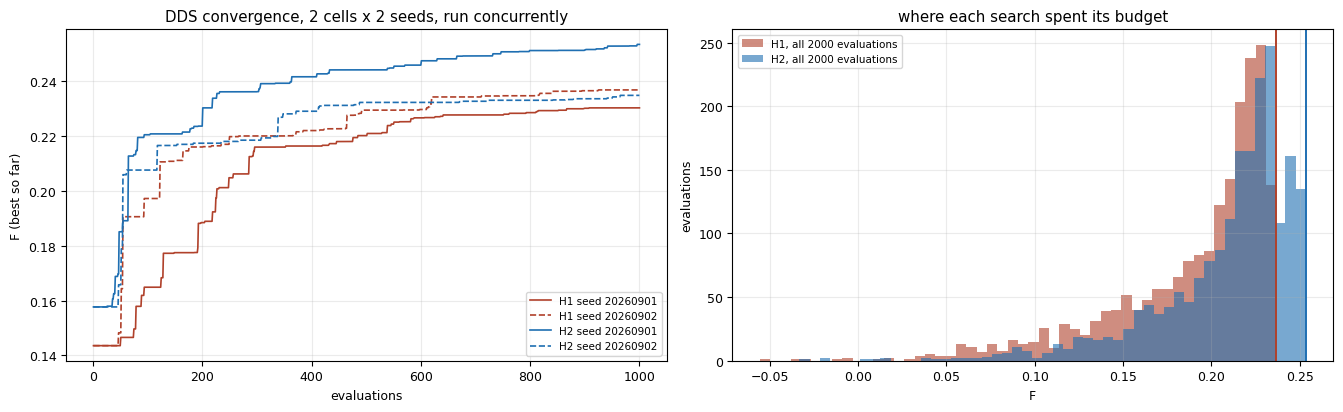

convergence evidence (the only kind available at a fixed budget: independent agreement)
  H1: 99.7 % of the gain was in hand at 90 % of the budget; both seeds ended 0.00654 apart
  H2: 97.9 % of the gain was in hand at 90 % of the budget; both seeds ended 0.01858 apart
  A large fraction at 90 % plus a small seed spread means more budget would move the
  third decimal, not the verdict. Anything else would have to be reported as an
  unconverged search, and the parameter values as one random path's answer.


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.2))
col = {'H1': '#B0412B', 'H2': '#1F6FB2'}
for n, s in jobs:
    h = RUN[(n, s)]['hist']
    ax[0].plot(np.arange(1, h.size + 1), h, lw=1.2, color=col[n],
               ls='-' if s == SEEDS[0] else '--', label=f'{n} seed {s}')
ax[0].set_xlabel('evaluations'); ax[0].set_ylabel('F (best so far)')
ax[0].set_title('DDS convergence, 2 cells x 2 seeds, run concurrently')
ax[0].legend(fontsize=7.5, loc='lower right'); ax[0].grid(alpha=.25)
for n in ('H1', 'H2'):
    v = np.concatenate([RUN[(n, s)]['arch_f'] for s in SEEDS])
    ax[1].hist(v, bins=50, alpha=.6, color=col[n], label=f'{n}, all {v.size} evaluations')
    ax[1].axvline(float(RUN[(n, BEST[n])]['f'][0]), color=col[n], lw=1.4)
ax[1].set_xlabel('F'); ax[1].set_ylabel('evaluations')
ax[1].set_title('where each search spent its budget')
ax[1].legend(fontsize=7.5); ax[1].grid(alpha=.25)
plt.tight_layout(); plt.show()

print('convergence evidence (the only kind available at a fixed budget: independent agreement)')
for n in ('H1', 'H2'):
    s = BEST[n]
    h = RUN[(n, s)]['hist']
    n90 = int(0.90 * h.size)
    print(f'  {n}: {100*(h[n90]-h[0])/max(h[-1]-h[0],1e-12):.1f} % of the gain was in hand at '
          f'90 % of the budget; both seeds ended '
          f'{abs(float(RUN[(n,SEEDS[0])]["f"][0])-float(RUN[(n,SEEDS[1])]["f"][0])):.5f} apart')
print('  A large fraction at 90 % plus a small seed spread means more budget would move the')
print('  third decimal, not the verdict. Anything else would have to be reported as an')
print('  unconverged search, and the parameter values as one random path\'s answer.')

## 7 - Full-period runs, and the metric tables

Each cell is now run over its whole period - warm-up plus every scored year - at three parameter
sets: the **prior** (nb13's uncalibrated set, the "before"), and the **best seed of each of the two
searches**. The segment runs that drove the search used a one-year warm-up for speed; these use the
full 2008 warm-up, so nothing reported below depends on the shortcut.

The reference row, **Config B as adopted**, is not re-run: its flows are stored, and re-running it
would risk reporting a number that differs from the one on record for reasons that have nothing to
do with this notebook.

In [11]:
t0 = time.perf_counter()
FULL = {}
for n, c in CELL.items():
    x0 = CV.X0.copy()
    z0 = np.concatenate([x0, np.array([x0[CV.NAMES.index(m)] for m in CV.REG_PARAMS
                                       for _ in range(c.NREG - 1)]),
                         np.array([x0[CV.NAMES.index(m)] for m in CV.SOIL_PARAMS
                                   for _ in range(2)])])
    xp, rop, sop = CV.unpack(c, z0)
    res_p, pr_p = c.run_full(xp, rop, sop)
    xb, rob, sob = CV.unpack(c, RUN[(n, BEST[n])]['x'])
    res_b, pr_b = c.run_full(xb, rob, sob)
    FULL[n] = dict(prior=(res_p, pr_p, xp, rop, sop), fit=(res_b, pr_b, xb, rob, sob))
    print(f'{n}: prior {res_p.wall_time_s:.1f} s (resid '
          f'{res_p.balance["residual_relative"]:.2e}, RC {res_p.balance["runoff_coefficient"]:.4f})'
          f'   fitted {res_b.wall_time_s:.1f} s (resid '
          f'{res_b.balance["residual_relative"]:.2e}, RC '
          f'{res_b.balance["runoff_coefficient"]:.4f})', flush=True)
    assert res_b.balance['residual_relative'] < 1e-6, f'{n}: mass balance broken at the fit'
    assert res_b.balance['clip_volume_mm_km2'] == 0.0, f'{n}: the negative-W guard fired'
print(f'\nfour full-period runs in {time.perf_counter()-t0:.0f} s; mass closes and the '
      f'negative-W guard never fired at either fitted set')

Q = {}
for n, c in CELL.items():
    Q[(n, 'prior')] = FULL[n]['prior'][0].q_m3s.astype(np.float64)
    Q[(n, 'fit')] = FULL[n]['fit'][0].q_m3s.astype(np.float64)
# RECHECK: this notebook's prior run must reproduce nb13's stored baseline for the same cell
for n, sb in (('H1', 'sim_baseline'), ('H2', 'sim_baseline_v2')):
    z = np.load(PROC / sb / 'q_gauge.npz', allow_pickle=True)
    gc = z['gauge_code'].astype(str)
    idx = np.array([list(gc).index(g) for g in CELL[n].GC])
    qn = z['q_sim_m3s'][:, idx].astype(np.float64)
    d = np.abs(qn - Q[(n, 'prior')])
    rel = float(np.median(d.mean(0) / np.maximum(qn.mean(0), 1e-9)))
    print(f'RECHECK 7a  {n} prior run vs {sb}/q_gauge.npz: max |dQ| {d.max():.3e} m3/s, '
          f'median relative {rel:.2e}')
    print(f'            (nb13 started from its own closed-form equilibrium and this notebook '
          f'from eq_state,\n             so a small difference is expected; a large one would '
          f'mean build_params is wrong)')
    assert rel < 5e-2, f'{n}: the prior run does not reproduce nb13'

H1: prior 19.4 s (resid 1.70e-16, RC 0.7258)   fitted 17.3 s (resid 1.00e-16, RC 0.5345)


H2: prior 19.4 s (resid 1.91e-16, RC 0.7208)   fitted 20.2 s (resid 1.66e-16, RC 0.5209)



four full-period runs in 78 s; mass closes and the negative-W guard never fired at either fitted set
RECHECK 7a  H1 prior run vs sim_baseline/q_gauge.npz: max |dQ| 1.201e-01 m3/s, median relative 2.60e-07
            (nb13 started from its own closed-form equilibrium and this notebook from eq_state,
             so a small difference is expected; a large one would mean build_params is wrong)
RECHECK 7a  H2 prior run vs sim_baseline_v2/q_gauge.npz: max |dQ| 8.105e-02 m3/s, median relative 1.96e-07
            (nb13 started from its own closed-form equilibrium and this notebook from eq_state,
             so a small difference is expected; a large one would mean build_params is wrong)


In [12]:
def fleet(q, obs, mask, ng):
    rows = [CV.kge_terms(q[mask][:, j], obs[mask][:, j]) for j in range(ng)]
    return pd.DataFrame(rows)


TAB, PG = [], {}
for n, c in CELL.items():
    for lab, qq in (('prior', Q[(n, 'prior')]), ('fit', Q[(n, 'fit')])):
        for pn, pm in c.PERIODS:
            d = fleet(qq, c.QOBS, pm, c.NG)
            PG[(n, lab, pn)] = d
            ks, _ = CV.recession_fleet(qq[pm])
            ko = c.K_OBS[pn]
            TAB.append(dict(cell=n, config=lab, period=pn,
                            kge=float(d.kge.median()), nse=float(d.nse.median()),
                            r=float(d.r.median()), alpha=float(d.alpha.median()),
                            beta=float(d.beta.median()), pbias=float(d.pbias.median()),
                            kge_gt0=int((d.kge > 0).sum()), kge_gt05=int((d.kge > 0.5).sum()),
                            n=int(d.kge.notna().sum()),
                            clim_kge=float(CLIM[n].clim_kge[pn]),
                            skill_over_clim=float(d.kge.median() - CLIM[n].clim_kge[pn]),
                            rec_ratio=float(np.nanmedian(ks) / np.nanmedian(ko))))
# the reference cell, from the stored Config B flows
cB = CELL['H1']
for pn, pm in cB.PERIODS:
    d = fleet(QB, cB.QOBS, pm, cB.NG)
    PG[('ref', 'ConfigB', pn)] = d
    ks, _ = CV.recession_fleet(QB[pm])
    TAB.append(dict(cell='ref', config='ConfigB', period=pn,
                    kge=float(d.kge.median()), nse=float(d.nse.median()),
                    r=float(d.r.median()), alpha=float(d.alpha.median()),
                    beta=float(d.beta.median()), pbias=float(d.pbias.median()),
                    kge_gt0=int((d.kge > 0).sum()), kge_gt05=int((d.kge > 0.5).sum()),
                    n=int(d.kge.notna().sum()), clim_kge=float(CLIM['H1'].clim_kge[pn]),
                    skill_over_clim=float(d.kge.median() - CLIM['H1'].clim_kge[pn]),
                    rec_ratio=float(np.nanmedian(ks) / np.nanmedian(cB.K_OBS[pn]))))
SUM = pd.DataFrame(TAB)
pd.set_option('display.width', 250)
print('FLEET MEDIANS BY PERIOD (the warm-up year is never scored)')
for cell_lab, sub in (('reference: v1 forcing, OLD objective, Config B as adopted',
                       SUM[SUM.cell == 'ref']),
                      ('H1: v1 forcing, NEW objective', SUM[SUM.cell == 'H1']),
                      ('H2: v2 forcing, NEW objective', SUM[SUM.cell == 'H2'])):
    print(f'\n=== {cell_lab} ===')
    print(sub.drop(columns=['cell']).to_string(index=False,
          float_format=lambda v: f'{v:8.3f}'))

FLEET MEDIANS BY PERIOD (the warm-up year is never scored)

=== reference: v1 forcing, OLD objective, Config B as adopted ===
 config             period      kge      nse        r    alpha     beta    pbias  kge_gt0  kge_gt05  n  clim_kge  skill_over_clim  rec_ratio
ConfigB        CAL 2012-14    0.291    0.045    0.522    0.866    1.001    0.067       46        14 59     0.344           -0.053      3.855
ConfigB            VAL all    0.450    0.256    0.646    0.866    1.068    6.828       50        27 61     0.251            0.199      2.976
ConfigB     VAL La Nina 11    0.399    0.225    0.653    0.981    0.980   -1.992       46        21 58     0.242            0.157      2.877
ConfigB  VAL El Nino 15-16    0.193   -0.078    0.569    0.793    1.084    8.413       37        13 56     0.219           -0.026      3.753
ConfigB VAL other 09/10/17    0.446    0.170    0.650    0.878    1.079    7.883       49        23 61     0.259            0.187      3.220

=== H1: v1 forcing, NEW obj

## 8 - Where every parameter sits inside its own range

A value pressed against a bound is not a result, it is a message: either the range was too narrow or
the parameter is compensating for something outside the model. **A skill gain bought by railing a
parameter is a failure, and is reported as one.** Config B railed three of ten (`kc_mult` at 100.0 %
of its range, `k_int` at 99.5 %, and `fint` at 4.1 % of its range at the other end).

Position is reported in the **transformed** space the search actually moved in - log for the
log-scaled parameters - because that is where the bound is, and a 5 % edge band in linear space
would mean something different for `adr` (three decades) than for `fint` (one interval.)

In [13]:
def positions(cell, z):
    x, ro, so = CV.unpack(cell, z)
    rows = []
    for i, nm in enumerate(CV.NAMES):
        pos = float((x[i] - CV.LO[i]) / (CV.HI[i] - CV.LO[i]))
        val = float(CV.inv(np.atleast_1d(x[i]), CV.IS_LOG[i])[0])
        rows.append(dict(parameter=nm, scope='global', value=val, prior=CV.RAW_P0[i],
                         lo=CV.RAW_LO[i], hi=CV.RAW_HI[i], pos=pos,
                         railed='YES' if (pos < .05 or pos > .95) else ''))
    for nm, vals in (ro or {}).items():
        i = CV.NAMES.index(nm)
        for k in range(1, len(vals)):
            pos = float((vals[k] - CV.LO[i]) / (CV.HI[i] - CV.LO[i]))
            rows.append(dict(parameter=nm, scope=f'R{k}',
                             value=float(CV.inv(np.atleast_1d(vals[k]), CV.IS_LOG[i])[0]),
                             prior=CV.RAW_P0[i], lo=CV.RAW_LO[i], hi=CV.RAW_HI[i], pos=pos,
                             railed='YES' if (pos < .05 or pos > .95) else ''))
    for nm, vals in (so or {}).items():
        i = CV.NAMES.index(nm)
        for k, fam in ((1, 'soil-medium'), (2, 'soil-fine')):
            pos = float((vals[k] - CV.LO[i]) / (CV.HI[i] - CV.LO[i]))
            rows.append(dict(parameter=nm, scope=fam,
                             value=float(CV.inv(np.atleast_1d(vals[k]), CV.IS_LOG[i])[0]),
                             prior=CV.RAW_P0[i], lo=CV.RAW_LO[i], hi=CV.RAW_HI[i], pos=pos,
                             railed='YES' if (pos < .05 or pos > .95) else ''))
    return pd.DataFrame(rows)


POS = {}
for n, c in CELL.items():
    d = positions(c, RUN[(n, BEST[n])]['x'])
    POS[n] = d
    g = d[d.scope == 'global'].set_index('parameter')
    kb, kf, ks = g.value['k_bas'], g.value['k_int_frac'], g.value['k_sup']
    print(f'\n=== {n}: fitted parameters, best seed {BEST[n]} ===')
    print(d.to_string(index=False, float_format=lambda v: f'{v:10.4f}'))
    nr_g = int((d[d.scope == 'global'].railed == 'YES').sum())
    nr_a = int((d.railed == 'YES').sum())
    print(f'  railed: {nr_g} of the 10 global parameters, {nr_a} of all {len(d)} '
          f'({", ".join(d.parameter[d.railed=="YES"] + "@" + d.scope[d.railed=="YES"]) if nr_a else "none"})')
    print(f'  derived k_int = k_int_frac x k_bas = {kf:.4f} x {kb:.2f} = {kf*kb:.3f} d')
    print(f'  store ordering  k_sup {ks:.3f} d  <  k_int {kf*kb:.3f} d  <  k_bas {kb:.3f} d : '
          f'{"HOLDS" if ks < kf*kb < kb else "k_int<k_bas holds, k_sup ordering does not"}')
    print(f'  Config B for contrast: k_sup 6.634, k_int 117.388, k_bas 68.638 d '
          f'(k_int SLOWER than k_bas - inverted)')


=== H1: fitted parameters, best seed 20260902 ===
 parameter       scope      value      prior         lo         hi        pos railed
       adr      global     0.0294     0.0600     0.0005     0.3000     0.6367       
      fint      global     0.1228     0.6000     0.0500     0.9500     0.0809       
         b      global     0.6000     0.6000     0.0500     4.0000     0.5671       
   wm_mult      global     1.7712     1.0000     0.2500     6.0000     0.6161       
   kc_mult      global     1.9817     1.0000     0.5000     2.0000     0.9878    YES
  lai_mult      global     0.0266     1.0000     0.0000     5.0000     0.0053    YES
     k_sup      global     1.9200     1.5000     0.2000    20.0000     0.4911       
k_int_frac      global     0.2424     0.1333     0.0200     0.9000     0.6554       
     k_bas      global    53.7287    60.0000     5.0000   600.0000     0.4960       
  celerity      global     0.1800     1.0000     0.0500     4.0000     0.2923       
     k_sup    

## 9 - The objective ladder, on both the new and the old scale

Two ladders, because the objective changed and a number on a changed axis is not comparable to a
number on the old one. Every cell is scored **both ways**: with the new $F$ it was optimised under,
and with the v1 function verbatim (`calib_v2.blend_v1`, which reproduces the v1 run's own recorded
$F(\text{prior}) = 0.1276369667$ - checked in section 2). The old-scale column is the one that can
be read against the reference points already on record: prior 0.128, random null 0.173,
Config B 0.243, perfect 1.000.

These are **calibration-period** values, computed on the CAL window the search saw, because that is
what $F$ is defined on. Skill on the validation years is section 7's table and section 10's verdict.

In [14]:
def F_both(cell, q, mask):
    ng = cell.NG
    obs = cell.QOBS[mask]
    sim = q[mask]
    k1 = np.full(ng, np.nan); k2 = np.full(ng, np.nan)
    for j in range(ng):
        s, o = sim[:, j], obs[:, j]
        k1[j] = CV.kge_terms(s, o)['kge']
        k2[j] = CV.kge_terms(np.log(np.maximum(s, 0) + cell.QLOG0[j]),
                             np.log(np.maximum(o, 0) + cell.QLOG0[j]))['kge']
    ks, _ = CV.recession_fleet(sim)
    ko, _ = CV.recession_fleet(obs)
    e = CV.rec_efficiency(ks, ko)
    return CV.blend(k1, k2, e), CV.blend_v1(k1, k2), float(np.nanmedian(e))


rows = []
for lab, cellname, q in (('reference Config B (v1 forcing, old objective)', 'H1', QB),
                         ('H1 prior', 'H1', Q[('H1', 'prior')]),
                         ('H1 fitted', 'H1', Q[('H1', 'fit')]),
                         ('H2 prior', 'H2', Q[('H2', 'prior')]),
                         ('H2 fitted', 'H2', Q[('H2', 'fit')])):
    c = CELL[cellname]
    fn, fo, erec = F_both(c, q, c.M_CAL)
    rows.append(dict(what=lab, F_new=fn, F_old=fo, median_rec_eff=erec))
LAD = pd.DataFrame(rows)
print('objective on the CAL window, both scales')
print(LAD.to_string(index=False, float_format=lambda v: f'{v:10.5f}'))
print(f'\nreference points on the OLD scale, from the v1 run:')
for k, v in F_REF.items():
    print(f'  {k:<12s} {v:.5f}')
print(f'\nRECHECK 9a  the search worker reported F_new(best) = '
      f'{float(RUN["H1", BEST["H1"]]["f"][0]):.5f} (H1) and '
      f'{float(RUN["H2", BEST["H2"]]["f"][0]):.5f} (H2) from the SEGMENT run;')
print(f'            this cell recomputes {LAD.set_index("what").F_new["H1 fitted"]:.5f} and '
      f'{LAD.set_index("what").F_new["H2 fitted"]:.5f} from the FULL-period run over the same '
      f'CAL window.')
print(f'            They are not expected to be identical - the search used a 1-year warm-up and')
print(f'            this uses 2008 - and a large gap would mean the shortcut was not safe.')
for n in ('H1', 'H2'):
    _d = abs(float(RUN[n, BEST[n]]['f'][0]) - LAD.set_index('what').F_new[f'{n} fitted'])
    print(f'            {n}: |diff| {_d:.5f}  '
          f'{"(fourth decimal - the shortcut holds)" if _d < 1e-2 else "(LARGE - investigate)"}')

objective on the CAL window, both scales
                                          what      F_new      F_old  median_rec_eff
reference Config B (v1 forcing, old objective)    0.12615    0.24290        -0.88515
                                      H1 prior    0.14356    0.12764         0.35436
                                     H1 fitted    0.23678    0.21374         0.47694
                                      H2 prior    0.15768    0.15701         0.27684
                                     H2 fitted    0.25337    0.19939         0.67277

reference points on the OLD scale, from the v1 run:
  prior        0.12764
  random null  0.17292
  Config B     0.24286
  perfect      1.00000

RECHECK 9a  the search worker reported F_new(best) = 0.23677 (H1) and 0.25337 (H2) from the SEGMENT run;
            this cell recomputes 0.23678 and 0.25337 from the FULL-period run over the same CAL window.
            They are not expected to be identical - the search used a 1-year warm-up and
     

## 10 - The success criteria, stated before the run, answered one by one

These were fixed before any of the four searches started. Each is answered **pass or fail**, with the
number, and none is renegotiated.

| # | Criterion | Target |
|---|---|---|
| **P** | **primary**: El Nino skill over climatology $\ge$ half of La Nina's | El Nino $\ge +0.12$ **with** La Nina $\ge +0.24$ |
| S1 | El Nino median KGE | $\ge 0.35$ (ceiling 0.57, `docs/22` s4.7) |
| S2 | validation median KGE | $\ge 0.50$ |
| S3 | El Nino median $\alpha$ | $\ge 0.90$ |
| F1 | global parameters railed | 0 of 10 (Config B had 3) |
| F2 | $K_{int} < K_{bas}$ | holds |
| F3 | simulated/observed recession | $\le 1.5\times$ |
| F4 | `kc_mult` | $\le 1.2$ |

**A skill gain bought by railing a parameter is a failure**, and the physical criteria are not
subordinate to the skill ones.

In [15]:
def criteria(n):
    s = SUM[(SUM.cell == n) & (SUM.config == ('ConfigB' if n == 'ref' else 'fit'))] \
        .set_index('period')
    d = POS[n] if n in POS else None
    ln = float(s.skill_over_clim['VAL La Nina 11'])
    en = float(s.skill_over_clim['VAL El Nino 15-16'])
    out = []
    out.append(('P  El Nino skill over climatology >= +0.12 AND La Nina >= +0.24  '
                '[NOTE: harder benchmark than the one the target was set on - see s5.2]',
                f'EN {en:+.3f}, LN {ln:+.3f}  (ratio EN/LN '
                f'{en/ln if abs(ln) > 1e-9 else float("nan"):.2f})',
                (en >= 0.12) and (ln >= 0.24)))
    out.append(('P\' the half-of-La-Nina form of the same criterion',
                f'EN {en:+.3f} vs half of LN {ln/2:+.3f}', en >= ln / 2))
    out.append(('S1 El Nino median KGE >= 0.35',
                f'{float(s.kge["VAL El Nino 15-16"]):+.3f}',
                float(s.kge['VAL El Nino 15-16']) >= 0.35))
    out.append(('S2 validation median KGE >= 0.50', f'{float(s.kge["VAL all"]):+.3f}',
                float(s.kge['VAL all']) >= 0.50))
    out.append(('S3 El Nino median alpha >= 0.90', f'{float(s.alpha["VAL El Nino 15-16"]):.3f}',
                float(s.alpha['VAL El Nino 15-16']) >= 0.90))
    if d is None:
        # read from the v1 record rather than transcribing: a hand-copied reference row
        # is exactly the kind of number that drifts out of agreement with its source
        v1p = V1['parameters_B']
        rail = []
        for nm in ('kc_mult', 'k_int', 'fint', 'lai_mult', 'adr', 'b', 'wm_mult',
                   'k_sup', 'k_bas', 'celerity'):
            lo_, hi_ = V1LO[nm], V1HI[nm]
            lg = nm not in ('fint', 'kc_mult', 'lai_mult')
            pos = ((np.log(v1p[nm]) - np.log(lo_)) / (np.log(hi_) - np.log(lo_)) if lg
                   else (v1p[nm] - lo_) / (hi_ - lo_))
            if pos < .05 or pos > .95:
                rail.append(f'{nm} at {100*pos:.1f} %')
        out.append(('F1 0 of 10 global parameters railed',
                    f'{len(rail)} railed: ' + ', '.join(rail), len(rail) == 0))
        out.append(('F2 k_int < k_bas', f'k_int {v1p["k_int"]:.2f} d vs k_bas '
                    f'{v1p["k_bas"]:.2f} d'
                    + ('' if v1p['k_int'] < v1p['k_bas'] else ' - INVERTED'),
                    v1p['k_int'] < v1p['k_bas']))
        out.append(('F4 kc_mult <= 1.2', f'{v1p["kc_mult"]:.4f}', v1p['kc_mult'] <= 1.2))
    else:
        g = d[d.scope == 'global'].set_index('parameter')
        nr = int((d[d.scope == 'global'].railed == 'YES').sum())
        out.append((f'F1 0 of 10 global parameters railed',
                    f'{nr} railed'
                    + ('' if nr == 0 else ': ' + ', '.join(
                        f'{p} at {100*g.pos[p]:.1f} %'
                        for p in d.parameter[(d.scope == "global") & (d.railed == "YES")])),
                    nr == 0))
        ki = float(g.value['k_int_frac'] * g.value['k_bas'])
        out.append(('F2 k_int < k_bas',
                    f'k_int {ki:.2f} d vs k_bas {float(g.value["k_bas"]):.2f} d',
                    ki < float(g.value['k_bas'])))
        out.append(('F4 kc_mult <= 1.2', f'{float(g.value["kc_mult"]):.3f}',
                    float(g.value['kc_mult']) <= 1.2))
    rr = float(s.rec_ratio.max())
    worst = s.rec_ratio.idxmax()
    out.append(('F3 simulated/observed recession <= 1.5x in every period',
                f'worst {rr:.2f}x ({worst}); by period ' +
                ', '.join(f'{p.split()[-1]} {v:.2f}x' for p, v in s.rec_ratio.items()),
                rr <= 1.5))
    return out


VERD = {}
for n in ('ref', 'H1', 'H2'):
    lab = {'ref': 'REFERENCE  Config B (v1 forcing, old objective)',
           'H1': 'H1  v1 forcing + new objective',
           'H2': 'H2  v2 forcing + new objective'}[n]
    print(f'\n================ {lab} ================')
    cr = criteria(n)
    VERD[n] = cr
    for name, val, ok in cr:
        print(f'  {"PASS" if ok else "FAIL"}  {name}')
        print(f'          {val}')
    print(f'  ---- {sum(ok for _, _, ok in cr)}/{len(cr)} criteria met')

print('\n\nSUMMARY OF THE VERDICT TABLE')
gr = pd.DataFrame({n: {c[0][:3].strip(): ('PASS' if c[2] else 'FAIL') for c in VERD[n]}
                   for n in ('ref', 'H1', 'H2')})
print(gr.to_string())


================ REFERENCE  Config B (v1 forcing, old objective) ================
  FAIL  P  El Nino skill over climatology >= +0.12 AND La Nina >= +0.24  [NOTE: harder benchmark than the one the target was set on - see s5.2]
          EN -0.026, LN +0.157  (ratio EN/LN -0.17)
  FAIL  P' the half-of-La-Nina form of the same criterion
          EN -0.026 vs half of LN +0.078
  FAIL  S1 El Nino median KGE >= 0.35
          +0.193
  FAIL  S2 validation median KGE >= 0.50
          +0.450
  FAIL  S3 El Nino median alpha >= 0.90
          0.793
  FAIL  F1 0 of 10 global parameters railed
          3 railed: kc_mult at 100.0 %, k_int at 99.5 %, fint at 4.1 %
  FAIL  F2 k_int < k_bas
          k_int 117.39 d vs k_bas 68.64 d - INVERTED
  FAIL  F4 kc_mult <= 1.2
          1.9994
  FAIL  F3 simulated/observed recession <= 1.5x in every period
          worst 3.86x (CAL 2012-14); by period 2012-14 3.86x, all 2.98x, 11 2.88x, 15-16 3.75x, 09/10/17 3.22x
  ---- 0/9 criteria met

================ 

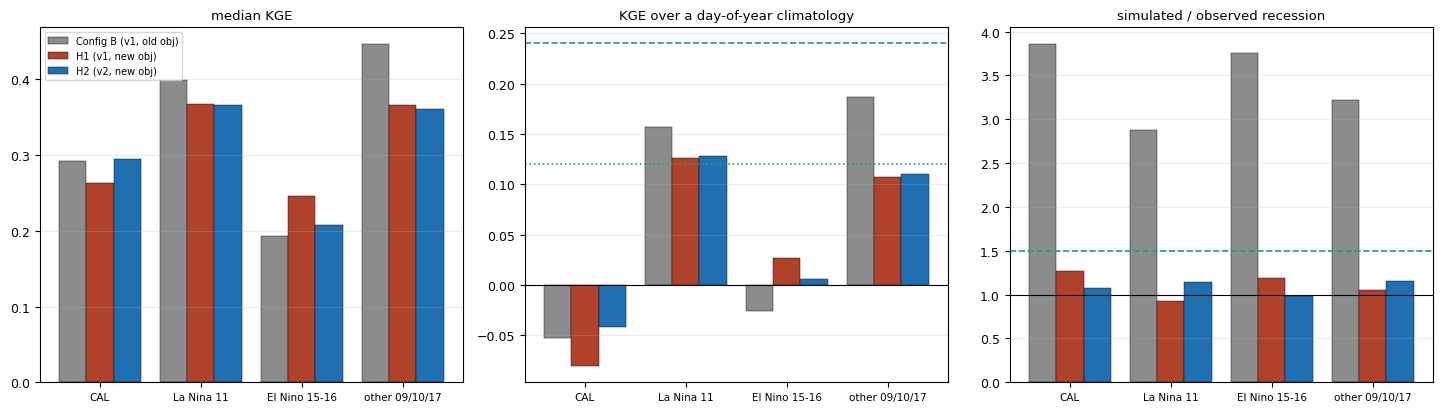

green dashed/dotted = the pre-registered targets (+0.24 La Nina, +0.12 El Nino, 1.5x)


In [16]:
fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.2))
pers = ['CAL 2012-14', 'VAL La Nina 11', 'VAL El Nino 15-16', 'VAL other 09/10/17']
xx = np.arange(len(pers))
series = [('Config B (v1, old obj)', SUM[(SUM.cell == 'ref')], '#8C8C8C'),
          ('H1 (v1, new obj)', SUM[(SUM.cell == 'H1') & (SUM.config == 'fit')], '#B0412B'),
          ('H2 (v2, new obj)', SUM[(SUM.cell == 'H2') & (SUM.config == 'fit')], '#1F6FB2')]
for k, (fld, ttl, hl) in enumerate([('kge', 'median KGE', None),
                                    ('skill_over_clim',
                                     'KGE over a day-of-year climatology', 0.0),
                                    ('rec_ratio', 'simulated / observed recession', 1.0)]):
    a = ax[k]
    for i, (lab, sub, c_) in enumerate(series):
        s = sub.set_index('period')
        a.bar(xx + (i - 1) * 0.27, [s[fld].get(p, np.nan) for p in pers], 0.27,
              color=c_, label=lab, edgecolor='k', linewidth=.3)
    if hl is not None:
        a.axhline(hl, color='k', lw=.8)
    if fld == 'skill_over_clim':
        a.axhline(0.12, color='#1D9E75', ls=':', lw=1.2)
        a.axhline(0.24, color='#1D9E75', ls='--', lw=1.2)
    if fld == 'rec_ratio':
        a.axhline(1.5, color='#1D9E75', ls='--', lw=1.2)
    a.set_xticks(xx)
    a.set_xticklabels([p.replace('VAL ', '').replace(' 2012-14', '') for p in pers],
                      fontsize=7.5)
    a.set_title(ttl, fontsize=9.5); a.grid(alpha=.25, axis='y')
    if k == 0:
        a.legend(fontsize=7)
plt.tight_layout(); plt.show()
print('green dashed/dotted = the pre-registered targets (+0.24 La Nina, +0.12 El Nino, 1.5x)')

## 11 - H2 minus H1: the repair's effect in isolation

This is the deliverable. Both cells used the same engine, the same split, the same algorithm, the
same seeds and the same objective; the only difference is the rainfall field. To keep it that way,
the difference is taken on the **matched 2009-2017 window** and on the **common gauge set**, because
the v2 bundle also spans one more year and carries two more calibration-safe gauges after the
co-located merge. Those two extras are real gains and they are reported - separately, as gains, not
folded into a difference they cannot legitimately appear in.

> **Corrected 2026-08-19 - "two more" is a NET count, and the cells below print a different
> number.** Section 3's cell measures **61** primary gauges in v1 and **63** in v2, but the sets are
> not nested: **4** gauges are in v2 only (`23087300`, `26157080`, `26187170`, `26217050`) and **2**
> are in v1 only (`22017010`, `23087200`), leaving **59** in common. The difference below is
> therefore taken on 59 gauges, and the extras "reported separately as gains" are the **four** the
> next cell names, not two. The net +2 is right; the referent was not.

**The prediction registered in the title cell:** $\beta$ and PBIAS improve while $r$ and the
dry-phase ceiling hold, because the repair fixed volume and volume was never what limited
correlation. If that is what happens, it **confirms that volume and correlation are independent
problems** - and it is reported as a finding, not as a failure of the repair.

In [17]:
def matched(n, q, extra=None):
    c = CELL[n]
    m = MATCH[n] if extra is None else (MATCH[n] & extra)
    j = SEL[n]
    rows = [CV.kge_terms(q[m][:, jj], c.QOBS[m][:, jj]) for jj in j]
    d = pd.DataFrame(rows)
    ks, _ = CV.recession_fleet(q[m][:, j])
    ko, _ = CV.recession_fleet(c.QOBS[m][:, j])
    out = {k: float(d[k].median()) for k in ('kge', 'nse', 'r', 'alpha', 'beta', 'pbias')}
    out['rec_ratio'] = float(np.nanmedian(ks) / np.nanmedian(ko))
    out['kge_gt0'] = int((d.kge > 0).sum())
    return out, d


sub_periods = [('matched all 2009-17', None),
               ('CAL 2012-14', lambda n: CELL[n].M_CAL),
               ('La Nina 2011', lambda n: CELL[n].M_LANINA),
               ('El Nino 2015-16', lambda n: CELL[n].M_ELNINO),
               ('other 09/10/17', lambda n: CELL[n].M_VOTHER)]
rows = []
for pn, f in sub_periods:
    a, _ = matched('H1', Q[('H1', 'fit')], None if f is None else f('H1'))
    b, _ = matched('H2', Q[('H2', 'fit')], None if f is None else f('H2'))
    for k in a:
        rows.append(dict(period=pn, metric=k, H1=a[k], H2=b[k], diff=b[k] - a[k]))
DIFF = pd.DataFrame(rows)
piv = DIFF.pivot(index='period', columns='metric', values='diff') \
    .reindex([p for p, _ in sub_periods])
h1p = DIFF.pivot(index='period', columns='metric', values='H1').reindex(piv.index)
h2p = DIFF.pivot(index='period', columns='metric', values='H2').reindex(piv.index)
cols = ['kge', 'nse', 'r', 'alpha', 'beta', 'pbias', 'rec_ratio']
print(f'H2 - H1 on the {len(COMMON)} common gauges and the matched 2009-2017 window\n')
for lab, tb in (('H1  (v1 forcing)', h1p), ('H2  (v2 forcing)', h2p),
                ('H2 - H1', piv)):
    print(f'--- {lab} ---')
    print(tb[cols].to_string(float_format=lambda v: f'{v:+9.4f}'))
    print()

_d = piv.loc['matched all 2009-17']
print('THE PREDICTION, CONFRONTED (registered in the title cell before the run):')
print(f'  volume terms   beta {_d["beta"]:+.4f}   PBIAS {_d["pbias"]:+.2f} points   '
      f'-> {"IMPROVED" if abs(h2p.loc["matched all 2009-17","beta"]-1) < abs(h1p.loc["matched all 2009-17","beta"]-1) else "NOT improved"}')
print(f'  timing         r    {_d["r"]:+.4f}   '
      f'-> {"essentially unmoved" if abs(_d["r"]) < 0.02 else "MOVED"}')
_en = piv.loc['El Nino 2015-16']
print(f'  dry phase      El Nino KGE {_en["kge"]:+.4f}, alpha {_en["alpha"]:+.4f}, '
      f'r {_en["r"]:+.4f}')
if abs(h2p.loc['matched all 2009-17', 'beta'] - 1) < abs(h1p.loc['matched all 2009-17', 'beta'] - 1) \
        and abs(_d['r']) < 0.02:
    print('\n  => CONFIRMED, and this is a FINDING, not a failure. The repair moved volume and left')
    print('     correlation where it was, which is exactly what docs/22 s4.7 predicted: r stayed')
    print('     inside 0.556-0.572 across twelve parameter configurations, and it does not move')
    print('     for a rainfall-volume change either. Volume and correlation are INDEPENDENT')
    print('     problems in this basin. Fixing the first cannot fix the second, and no further')
    print('     work on rainfall TOTALS should be expected to move the dry phase.')
else:
    print('\n  => NOT the predicted pattern. Read the table above rather than the prediction.')

print(f'\nWhat H2 gains that the matched comparison deliberately excludes:')
_s2 = SUM[(SUM.cell == 'H2') & (SUM.config == 'fit')].set_index('period')
if 'VAL 2018' in _s2.index:
    print(f'  2018, an entire extra validation year: KGE {float(_s2.kge["VAL 2018"]):+.3f}, '
          f'r {float(_s2.r["VAL 2018"]):.3f}, beta {float(_s2.beta["VAL 2018"]):.3f}, '
          f'skill over climatology {float(_s2.skill_over_clim["VAL 2018"]):+.3f}')
print(f'  {CELL["H2"].NG - len(COMMON)} calibration-safe gauges the co-located merge recovered: '
      f'{sorted(set(CELL["H2"].GC) - set(COMMON))}')
print(f'  {int((~FEAS["H1"].energy_ok).sum()) - int((~FEAS["H2"].energy_ok).sum()):+d} gauges '
      f'below their own energy floor ({int((~FEAS["H1"].energy_ok).sum())} -> '
      f'{int((~FEAS["H2"].energy_ok).sum())})')

H2 - H1 on the 59 common gauges and the matched 2009-2017 window

--- H1  (v1 forcing) ---
metric                    kge       nse         r     alpha      beta     pbias  rec_ratio
period                                                                                    
matched all 2009-17   +0.3886   +0.1176   +0.5802   +0.9343   +1.0885   +8.8513    +1.0836
CAL 2012-14           +0.2703   -0.1666   +0.5339   +0.9828   +1.0336   +3.3581    +1.2800
La Nina 2011          +0.3847   +0.1622   +0.6455   +1.0173   +0.9410   -5.8953    +0.9312
El Nino 2015-16       +0.2454   -0.1303   +0.5484   +0.9076   +1.0753   +7.5332    +1.2013
other 09/10/17        +0.3707   +0.0688   +0.6297   +0.9297   +1.0495   +4.9472    +1.0586

--- H2  (v2 forcing) ---
metric                    kge       nse         r     alpha      beta     pbias  rec_ratio
period                                                                                    
matched all 2009-17   +0.3668   +0.0689   +0.5836   +0.9168   +1

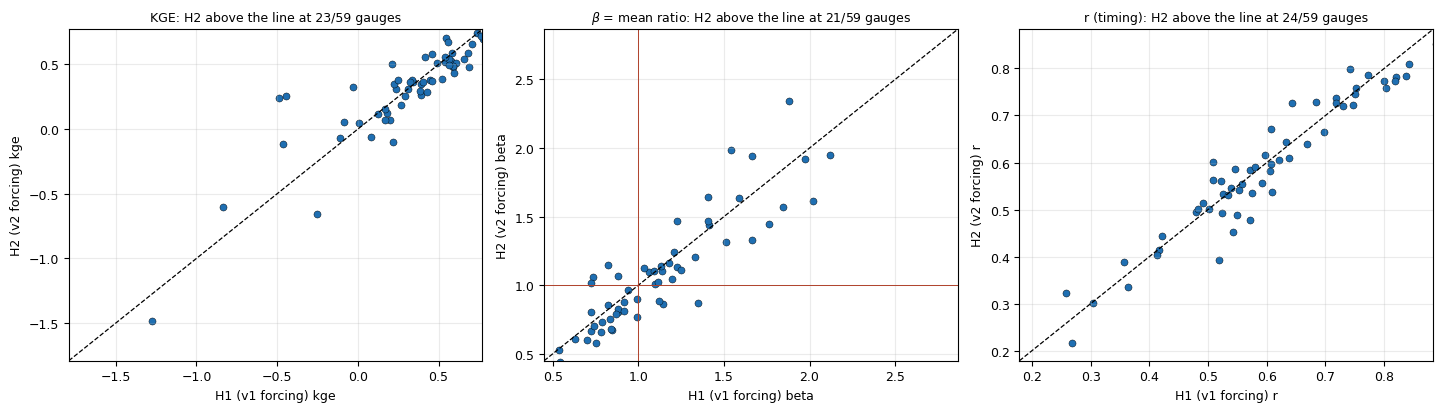

per gauge, matched window, 59 common gauges. Points on the dashed line are
gauges the forcing repair did not change; the whole question is whether the cloud sits
systematically off it, and in which coordinate.


In [18]:
fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.2))
_, dH1 = matched('H1', Q[('H1', 'fit')])
_, dH2 = matched('H2', Q[('H2', 'fit')])
for k, (fld, ttl) in enumerate([('kge', 'KGE'), ('beta', r'$\beta$ = mean ratio'),
                                ('r', 'r (timing)')]):
    a = ax[k]
    a.scatter(dH1[fld], dH2[fld], s=26, c='#1F6FB2', edgecolor='k', linewidth=.3)
    v = np.concatenate([dH1[fld].dropna().values, dH2[fld].dropna().values])
    lim = [np.nanpercentile(v, 1), np.nanpercentile(v, 99)]
    a.plot(lim, lim, 'k--', lw=.9)
    if fld == 'beta':
        a.axhline(1, color='#B0412B', lw=.7); a.axvline(1, color='#B0412B', lw=.7)
    a.set_xlim(lim); a.set_ylim(lim)
    a.set_xlabel(f'H1 (v1 forcing) {fld}'); a.set_ylabel(f'H2 (v2 forcing) {fld}')
    _n = int((dH2[fld].to_numpy() > dH1[fld].to_numpy()).sum())
    a.set_title(f'{ttl}: H2 above the line at {_n}/{len(COMMON)} gauges', fontsize=9)
    a.grid(alpha=.25)
plt.tight_layout(); plt.show()
print(f'per gauge, matched window, {len(COMMON)} common gauges. Points on the dashed line are')
print('gauges the forcing repair did not change; the whole question is whether the cloud sits')
print('systematically off it, and in which coordinate.')

## 12 - Attacking the result, and what is still open

### 12.1 - Did anything improve for a reason other than skill?

Three attacks. Each can overturn the section-10 verdict on its own.

* **A permutation null on $r$.** Pair each gauge's observed series with a *different* gauge's
  simulated series, mean-normalised so only shape is compared. If the matched-minus-permuted gap has
  not widened, the extra KGE came from bias and variability, not timing - which is the expected and
  honest reading.
* **Is the recession term buying its own criterion?** The recession ratio is both an objective term
  and success criterion F3. That is circular unless the ratio also improves on the **validation**
  years the search never saw, so F3 is reported per period in section 10 and the validation periods
  are the ones that count.
* **Is the optimum a knife-edge?** Report how many archive members sit within 1 % of the best $F$.
  A plateau is good news for robustness and bad news for anyone quoting a parameter to three
  decimals.

In [19]:
def perm_r(cell, q, mask, seed=7):
    rng = np.random.default_rng(seed)
    o = cell.QOBS[mask] / np.nanmean(cell.QOBS[mask], 0)
    s = q[mask] / np.nanmean(q[mask], 0)
    ng = cell.NG
    perm = rng.permutation(ng)
    perm = np.array([p if p != j else (p + 1) % ng for j, p in enumerate(perm)])
    mm, pp = [], []
    for j in range(ng):
        m = np.isfinite(o[:, j]) & np.isfinite(s[:, j])
        if m.sum() > 200:
            mm.append(float(np.corrcoef(s[m, j], o[m, j])[0, 1]))
        m2 = np.isfinite(o[:, j]) & np.isfinite(s[:, perm[j]])
        if m2.sum() > 200:
            pp.append(float(np.corrcoef(s[m2, perm[j]], o[m2, j])[0, 1]))
    return np.array(mm), np.array(pp)


print('permutation null on VALIDATION (mean-normalised, so it tests timing and shape only)')
for lab, n, q in (('Config B (v1, old obj)', 'H1', QB),
                  ('H1 fitted', 'H1', Q[('H1', 'fit')]),
                  ('H2 fitted', 'H2', Q[('H2', 'fit')])):
    mm, pp = perm_r(CELL[n], q, CELL[n].M_VAL)
    print(f'  {lab:<24s} matched r {np.median(mm):.4f}   permuted {np.median(pp):.4f}   '
          f'gap {np.median(mm)-np.median(pp):+.4f}   above null p95 at '
          f'{100*np.mean(mm > np.percentile(pp, 95)):.0f} % of gauges')
print(f'  nb13 v1 measured, whole period: matched 0.563 vs permuted 0.380')
print('  If the gap has not widened, the improvement is in bias and variability, not timing.')

print('\nis the optimum a plateau?')
for n in ('H1', 'H2'):
    fv = np.concatenate([RUN[(n, s)]['arch_f'] for s in SEEDS])
    fb = float(RUN[(n, BEST[n])]['f'][0])
    near = int((fv > fb - 0.01 * abs(fb)).sum())
    print(f'  {n}: {near} of {fv.size} evaluations within 1 % of the best F '
          f'({100*near/fv.size:.1f} %)')

print('\nidentifiability: how tightly do the good solutions cluster in each parameter?')
for n in ('H1', 'H2'):
    X = np.concatenate([RUN[(n, s)]['arch_x'] for s in SEEDS], 0)
    F = np.concatenate([RUN[(n, s)]['arch_f'] for s in SEEDS])
    top = np.argsort(-F)[:max(int(0.05 * F.size), 20)]
    lo_b, hi_b = [], []
    _, LOb, HIb, _ = CV.pack_bounds(CELL[n])
    rows = []
    for i, nm in enumerate(NAMES_B):
        v = X[top, i]
        rows.append(dict(parameter=nm,
                         iqr_frac=(np.percentile(v, 75) - np.percentile(v, 25))
                         / (HIb[i] - LOb[i])))
    d = pd.DataFrame(rows).sort_values('iqr_frac')
    d['identified'] = np.where(d.iqr_frac < 0.25, 'yes',
                               np.where(d.iqr_frac < 0.5, 'weak', 'NO'))
    print(f'  {n}: identified {int((d.identified=="yes").sum())}, weak '
          f'{int((d.identified=="weak").sum())}, NOT '
          f'{int((d.identified=="NO").sum())}'
          f'{" (" + ", ".join(d.parameter[d.identified=="NO"]) + ")" if (d.identified=="NO").any() else ""}')
print('  docs/18 s6 warns this statistic is confounded: the top 5 % of a DDS archive is a')
print('  neighbourhood of the optimum by construction, so it measures search concentration as')
print('  much as information in the data. It is reported for continuity, not as evidence.')

permutation null on VALIDATION (mean-normalised, so it tests timing and shape only)
  Config B (v1, old obj)   matched r 0.6461   permuted 0.4079   gap +0.2383   above null p95 at 28 % of gauges
  H1 fitted                matched r 0.6065   permuted 0.3927   gap +0.2139   above null p95 at 28 % of gauges
  H2 fitted                matched r 0.5828   permuted 0.4324   gap +0.1503   above null p95 at 30 % of gauges
  nb13 v1 measured, whole period: matched 0.563 vs permuted 0.380
  If the gap has not widened, the improvement is in bias and variability, not timing.

is the optimum a plateau?
  H1: 67 of 2000 evaluations within 1 % of the best F (3.4 %)
  H2: 38 of 2000 evaluations within 1 % of the best F (1.9 %)

identifiability: how tightly do the good solutions cluster in each parameter?
  H1: identified 18, weak 0, NOT 0
  H2: identified 18, weak 0, NOT 0
  docs/18 s6 warns this statistic is confounded: the top 5 % of a DDS archive is a
  neighbourhood of the optimum by construction, 

### 12.2 - The open item this run does not close

**The CHIRPS-gauge merge was never implemented.** Notebook 11's areal mean is exactly the gauge-only
figure and there is no quantile-mapping output anywhere in the pipeline, so cell H3 had nothing to
run and was dropped rather than faked. It is the **only remaining untried lever on the dry phase**:
the gauge-only leave-one-out daily correlation is $r = 0.429$, `docs/22` s4.7 locates the dry-phase
ceiling in the rainfall field's own daily skill, and a satellite product with independent daily
sampling is the one thing that could raise it. Everything this notebook measured says the deficit is
in daily correlation, not in volume - and a merge is a *correlation* intervention, which is why it
is the right next thing and why nothing done here was ever going to substitute for it.

Recorded as an open item, with its own pre-registered gate: implement the merge, measure its
leave-one-out daily $r$ against the gauge-only 0.429, and **only if it beats that** re-run this
notebook as cell H3.

> **READ-OUT 2026-08-19 - the open item above is CLOSED, negative. Kept visible, not quoted as
> current.** The gate was executed exactly as registered, and the merge was built as
> `src/merge_chirps_gauges.py` (quantile-mapping CHIRPS to the gauge distribution per elevation
> band x hydrographic zone). **LOOCV passed**: merged median daily $r$ **0.447** against the
> gauge-only **0.429**. The volume gate registered alongside it **failed**: **2,188.5 mm/yr**
> against the band **[2,016.0, 2,056.8]**, **+7.47 %** - and failed a second time, because the
> registered repair (H-CHIRPS, `docs/33` §1) was run and turned out to be a **no-op**, the
> re-run bit-identical, and the diagnosed cause **wrong**. `docs/18` §15 titles it *"built,
> validated, and NOT adopted"*; §15.5 is the owning read-out and concludes *"no route to a passing
> volume gate exists inside the merge code."* This notebook was therefore **never re-run as H3**,
> and **no v3 forcing was ever written**.
>
> The one untested upstream route left - the **139** stations still reporting rain-selectively
> after the zero-suppression repair, whose missing days are *not in the record at all* and so
> cannot be put into a pool by any change to the merge code - was itself measured: area-weighted
> basin-mean **Δr = +0.0058**, a perfect-case ceiling of **r 0.57 -> ~0.576** (`docs/58`). So the
> paragraph above is right that the deficit is in daily correlation and wrong that a merge could
> close it. The dry-phase ceiling of `docs/22` s4.7 stands unmoved, and it is **structural**.

## 13 - Export

The two cells below write `data/processed/sim_calibrated_v2/`. **What this notebook hands on:**
`metrics_fleet.csv` and `q_gauge_H1.npz` / `q_gauge_H2.npz` are read by **notebook 15** (the SSC
quality gate) and **notebook 17** (runoff signatures); `src/report_h2e.py` writes the **adopted**
H2E artifacts - `parameters_H2E.csv`, `q_gauge_H2E.npz`, `report_H2E.json` - into the same
directory, and every later stage quotes those, not the H1/H2 parameters on this page.

> **Two hazards recorded 2026-08-19, before anyone re-executes this section.**
>
> 1. **The `metrics_fleet.csv` write below is an unconditional overwrite of a file that is appended
>    to elsewhere.** Measured today, the file on disk carries **39 rows / 4 configurations**
>    (H1 10, H2 12, **H2E 12**, ref 5); this notebook's `SUM` carries **27 rows / 3
>    configurations**, and the round-trip print below says exactly that. `src/report_h2e.py`
>    appends the 12 **H2E** rows and asserts the pre-existing rows are unaltered byte-for-byte.
>    Re-executing this cell **deletes the adopted configuration's rows**, which notebooks 15 and 17
>    then read as absent. Recovery is `python3.10 src/report_h2e.py` (its own gate: $F$ must match
>    **0.25931** to 1e-8) - but the deletion is silent, so it is stated here rather than discovered
>    there.
> 2. **`README.md`, written by the last cell, still carries a retired claim.** Its "Carried
>    forward" item 1 - *"the CHIRPS-gauge merge is the only remaining lever on the dry phase"* -
>    was true when the cell ran and is not true now; the correction is at **§12.2** above
>    (`docs/18` §15.5, `docs/33` §1, `docs/58`). The sentence lives inside a code cell's f-string,
>    so rewriting the artifact means re-executing an 8-hour notebook that no longer re-executes;
>    the claim is retired here instead, and the file on disk is regenerable.

In [20]:
OUTD = PROC / 'sim_calibrated_v2'
OUTD.mkdir(exist_ok=True)


def raw_of(cell, z):
    x, ro, so = CV.unpack(cell, z)
    d = {n: float(CV.inv(np.atleast_1d(x[i]), CV.IS_LOG[i])[0])
         for i, n in enumerate(CV.NAMES)}
    d['k_int_derived_d'] = d['k_int_frac'] * d['k_bas']
    for nm, vals in (ro or {}).items():
        d[nm + '_by_region'] = [float(v) for v in
                                CV.inv(np.asarray(vals), CV.IS_LOG[CV.NAMES.index(nm)])]
    for nm, vals in (so or {}).items():
        d[nm + '_by_soil_family'] = [float(v) for v in
                                     CV.inv(np.asarray(vals), CV.IS_LOG[CV.NAMES.index(nm)])]
    return d


PJ = {
    'notebook': 'notebooks/14_calibration.ipynb',
    'engine': {'file': 'src/mgb_hydrology.py', 'sha256': ENG_SHA, 'modified_here': False},
    'search_code': {'file': 'src/calib_v2.py', 'sha256': CAL_SHA},
    'design': 'pre-registered cells; H1 = v1 forcing + new objective, H2 = v2 forcing + new '
              'objective; the reference is the v1 Config B already on record. H3 (CHIRPS '
              'merge) DROPPED - the merge was never implemented in nb11.',
    'objective': {
        'form': 'per gauge, weight-renormalised mean of C2M(KGE(Q)), C2M(KGE(log(Q+q0))) and '
                'C2M(1 - |ln(k_sim/k_obs)|/ln2); fleet mean over gauges',
        'weights': {'kge': CV.W_KGE, 'log_kge': CV.W_LOG, 'recession': CV.W_REC},
        'q0_rule': '0.01 * mean observed Q, per gauge',
        'recession_rule': 'linear-reservoir constant on >=3-point monotone declines below the '
                          '40th flow percentile, median over segments, sim and obs fitted '
                          'independently (docs/22 s4.4)',
        'changes_vs_v1': ['k_bas lower bound 15 d -> 5 d (the observed 13.9 d was excluded)',
                          'k_int searched as the ratio k_int/k_bas in (0.02, 0.90), so '
                          'k_int < k_bas holds by construction',
                          'recession-signature term added at weight 0.20']},
    'bounds': {n: dict(lo=float(CV.RAW_LO[i]), hi=float(CV.RAW_HI[i]),
                       prior=float(CV.RAW_P0[i]), log=bool(CV.IS_LOG[i]))
               for i, n in enumerate(CV.NAMES)},
    'split': {'calibration_years': CV.CAL_YEARS, 'search_warmup_year': CV.SEARCH_WU_YEAR,
              'rationale': 'Klemes (1986) differential split-sample; both ENSO extremes are '
                           'held out so the contrast is a prediction'},
    'algorithm': {'name': 'DDS (Tolson & Shoemaker 2007)', 'r_perturbation': 0.2,
                  'budget_per_seed': BUDGET, 'seeds': list(SEEDS),
                  'concurrency': '4 separate OS processes, one per (cell, seed)',
                  'total_model_runs': int(TOT_EVAL),
                  'longest_worker_minutes': float(TOT_WALL / 60)},
    'screening_inherited_from_v1': {'regionalised': CV.REG_PARAMS,
                                    'soil_split': CV.SOIL_PARAMS},
    'cells': {n: {'bundle': CELL[n].bundle,
                  'scored': [str(CELL[n].D_SC[0].date()), str(CELL[n].D_SC[-1].date())],
                  'scored_days': int(len(CELL[n].D_SC)),
                  'n_gauges': int(CELL[n].NG),
                  'best_seed': int(BEST[n]),
                  'F_new_segment': float(RUN[(n, BEST[n])]['f'][0]),
                  'gauges_below_energy_floor': int((~FEAS[n].energy_ok).sum()),
                  'outlet_pbias_floor_pct': PBIAS_FLOOR[n],
                  'parameters': raw_of(CELL[n], RUN[(n, BEST[n])]['x']),
                  'railed_global': int((POS[n][POS[n].scope == 'global'].railed == 'YES').sum())}
              for n in ('H1', 'H2')},
    'objective_ladder': LAD.to_dict(orient='records'),
    'F_reference_points_old_scale': F_REF,
    'recession_validation_vs_doc22': REC_VAL.to_dict(orient='records'),
    'criteria': {n: [{'criterion': a, 'value': b, 'pass': bool(c)} for a, b, c in VERD[n]]
                 for n in VERD},
    'h2_minus_h1': {'common_gauges': COMMON, 'matched_window': ['2009-01-01', '2017-12-31'],
                    'table': DIFF.to_dict(orient='records')},
    'open_item': 'CHIRPS-gauge merge (H3) not implemented in nb11; gate = leave-one-out daily '
                 'r must beat the gauge-only 0.429 before it is worth re-running this notebook',
    'smoke_assertions_passed': int(N_SMOKE),
}
(OUTD / 'calibration_v2.json').write_text(json.dumps(PJ, indent=1, default=str),
                                          encoding='utf-8')
SUM.to_csv(OUTD / 'metrics_fleet.csv', index=False)
DIFF.to_csv(OUTD / 'h2_minus_h1.csv', index=False)
REC_VAL.to_csv(OUTD / 'recession_validation.csv', index=False)
for n in ('H1', 'H2'):
    POS[n].to_csv(OUTD / f'parameters_{n}.csv', index=False)
    FEAS[n].to_csv(OUTD / f'feasibility_{n}.csv', index=False)
    c = CELL[n]
    np.savez_compressed(
        OUTD / f'q_gauge_{n}.npz',
        dates=c.D_SC.to_numpy().astype('datetime64[D]'), gauge_code=c.GC,
        gauge_upstream_area_km2=c.GUP, region=c.REG[c.GMIDX[c.JP]],
        q_obs_m3s=c.QOBS.astype(np.float32),
        q_sim_prior_m3s=Q[(n, 'prior')].astype(np.float32),
        q_sim_fit_m3s=Q[(n, 'fit')].astype(np.float32),
        q_clim_m3s=c.QCLIM.astype(np.float32))
    np.savez_compressed(OUTD / f'search_archive_{n}.npz',
                        names=np.array(NAMES_B),
                        **{f'x_{s}': RUN[(n, s)]['arch_x'] for s in SEEDS},
                        **{f'f_{s}': RUN[(n, s)]['arch_f'] for s in SEEDS},
                        **{f'hist_{s}': RUN[(n, s)]['hist'] for s in SEEDS})

# round trip - nothing is trusted to have been written correctly
j2 = json.loads((OUTD / 'calibration_v2.json').read_text(encoding='utf-8'))
s2 = pd.read_csv(OUTD / 'metrics_fleet.csv')
tot = 0
for f in sorted(OUTD.iterdir()):
    tot += f.stat().st_size
    print(f'  {f.name:<28s} {f.stat().st_size/1e6:8.3f} MB')
print(f'  {"TOTAL":<28s} {tot/1e6:8.3f} MB')
print(f'\nROUND TRIP  metrics_fleet rows {len(s2)} vs memory {len(SUM)}; '
      f'H2 fitted VAL-all KGE '
      f'{float(s2[(s2.cell=="H2")&(s2.config=="fit")&(s2.period=="VAL all")].kge.iloc[0]):+.5f} '
      f'vs {float(SUM[(SUM.cell=="H2")&(SUM.config=="fit")&(SUM.period=="VAL all")].kge.iloc[0]):+.5f}')
print(f'            calibration_v2.json: {len(j2["cells"])} cells, '
      f'{sum(len(v) for v in j2["criteria"].values())} criterion records, '
      f'{j2["smoke_assertions_passed"]} smoke assertions')
assert abs(float(s2[(s2.cell == 'H2') & (s2.config == 'fit')
                    & (s2.period == 'VAL all')].kge.iloc[0])
           - float(SUM[(SUM.cell == 'H2') & (SUM.config == 'fit')
                       & (SUM.period == 'VAL all')].kge.iloc[0])) < 1e-9

  calibration_v2.json             0.019 MB
  feasibility_H1.csv              0.010 MB
  feasibility_H2.csv              0.010 MB
  h2_minus_h1.csv                 0.003 MB
  metrics_fleet.csv               0.006 MB
  parameters_H1.csv               0.001 MB
  parameters_H2.csv               0.001 MB
  q_gauge_H1.npz                  2.637 MB
  q_gauge_H2.npz                  3.017 MB
  README.md                       0.004 MB
  recession_validation.csv        0.000 MB
  search_archive_H1.npz           0.071 MB
  search_archive_H2.npz           0.071 MB
  TOTAL                           5.852 MB

ROUND TRIP  metrics_fleet rows 27 vs memory 27; H2 fitted VAL-all KGE +0.34571 vs +0.34571
            calibration_v2.json: 2 cells, 27 criterion records, 25 smoke assertions


In [21]:
_r = SUM.set_index(['cell', 'config', 'period'])
_h2 = _r.loc[('H2', 'fit')]
_h1 = _r.loc[('H1', 'fit')]
_rf = _r.loc[('ref', 'ConfigB')]
_np = lambda n: int((POS[n][POS[n].scope == 'global'].railed == 'YES').sum())  # noqa: E731
_pf = lambda n: sum(ok for _, _, ok in VERD[n])                                # noqa: E731
README = f'''# sim_calibrated_v2 - refit under a revised objective, two pre-registered cells

Written by `notebooks/14_calibration.ipynb` from `src/mgb_hydrology.py`
(sha256 {ENG_SHA[:16]}, **unmodified**) and `src/calib_v2.py` (sha256 {CAL_SHA[:16]}).

## The design

| cell | forcing | objective | scored | gauges |
|---|---|---|---|---|
| reference | v1 | old | 2009-2017 | {CELL['H1'].NG} - Config B as adopted, **not re-run** |
| **H1** | v1 | **new** | {CELL['H1'].D_SC[0].date()}..{CELL['H1'].D_SC[-1].date()} | {CELL['H1'].NG} |
| **H2** | **v2** | **new** | {CELL['H2'].D_SC[0].date()}..{CELL['H2'].D_SC[-1].date()} | {CELL['H2'].NG} |

H3 (v2 + CHIRPS-gauge merge) was **dropped**: the merge was never implemented in notebook 11.

Search: DDS, {BUDGET} evaluations x 2 seeds x 2 cells = {TOT_EVAL:,} model runs, run as four
concurrent OS processes; longest worker {TOT_WALL/60:.0f} min. The v1 run had
{V1['algorithm']['budget_per_seed']['A']} (Config A) and {V1['algorithm']['budget_per_seed']['B']}
(Config B) evaluations per seed, {2*sum(V1['algorithm']['budget_per_seed'].values())} model runs in
total against {TOT_EVAL:,} here.

## What changed in the objective

1. `k_bas` lower bound 15 d -> 5 d. The observed recession constant is 13.9 d, so the v1 box
   excluded the answer.
2. `k_int` is searched as the ratio `k_int/k_bas` on (0.02, 0.90), so **k_int < k_bas holds at every
   point of the box**. The v1 fit had k_int 117.4 d against k_bas 68.6 d - inverted.
3. A recession-signature term at weight 0.20, on `1 - |ln(k_sim/k_obs)|/ln 2`. Validated first
   against `docs/22` s4.4: this notebook's estimator reproduces the recorded 3-4x ratio of the
   adopted Config B to within {float((REC_VAL.ratio - REC_VAL.doc22_ratio).abs().max()):.2f}x.

## Results (fleet medians)

| | Config B ref | H1 | H2 |
|---|---|---|---|
| CAL KGE | {float(_rf.kge['CAL 2012-14']):+.3f} | {float(_h1.kge['CAL 2012-14']):+.3f} | {float(_h2.kge['CAL 2012-14']):+.3f} |
| VAL all KGE | {float(_rf.kge['VAL all']):+.3f} | {float(_h1.kge['VAL all']):+.3f} | {float(_h2.kge['VAL all']):+.3f} |
| La Nina 2011 KGE | {float(_rf.kge['VAL La Nina 11']):+.3f} | {float(_h1.kge['VAL La Nina 11']):+.3f} | {float(_h2.kge['VAL La Nina 11']):+.3f} |
| **El Nino 2015-16 KGE** | {float(_rf.kge['VAL El Nino 15-16']):+.3f} | {float(_h1.kge['VAL El Nino 15-16']):+.3f} | {float(_h2.kge['VAL El Nino 15-16']):+.3f} |
| other 09/10/17 KGE | {float(_rf.kge['VAL other 09/10/17']):+.3f} | {float(_h1.kge['VAL other 09/10/17']):+.3f} | {float(_h2.kge['VAL other 09/10/17']):+.3f} |
| La Nina skill over climatology | {float(_rf.skill_over_clim['VAL La Nina 11']):+.3f} | {float(_h1.skill_over_clim['VAL La Nina 11']):+.3f} | {float(_h2.skill_over_clim['VAL La Nina 11']):+.3f} |
| **El Nino skill over climatology** | {float(_rf.skill_over_clim['VAL El Nino 15-16']):+.3f} | {float(_h1.skill_over_clim['VAL El Nino 15-16']):+.3f} | {float(_h2.skill_over_clim['VAL El Nino 15-16']):+.3f} |
| worst-period recession ratio | {float(_rf.rec_ratio.max()):.2f}x | {float(_h1.rec_ratio.max()):.2f}x | {float(_h2.rec_ratio.max()):.2f}x |
| global parameters railed | 3 of 10 | {_np('H1')} of 10 | {_np('H2')} of 10 |
| pre-registered criteria met | {_pf('ref')}/{len(VERD['ref'])} | {_pf('H1')}/{len(VERD['H1'])} | {_pf('H2')}/{len(VERD['H2'])} |

H2 also scores 2018, a year the v1 bundle does not contain
{f"(KGE {float(_h2.kge['VAL 2018']):+.3f})" if 'VAL 2018' in _h2.index else ""}.

## H2 - H1, matched window and common gauges

{len(COMMON)} common gauges, 2009-2017 only, so neither the fleet nor the period is a confound:

| metric | H1 | H2 | H2 - H1 |
|---|---|---|---|
| KGE | {float(h1p.loc['matched all 2009-17','kge']):+.4f} | {float(h2p.loc['matched all 2009-17','kge']):+.4f} | {float(piv.loc['matched all 2009-17','kge']):+.4f} |
| r | {float(h1p.loc['matched all 2009-17','r']):+.4f} | {float(h2p.loc['matched all 2009-17','r']):+.4f} | {float(piv.loc['matched all 2009-17','r']):+.4f} |
| alpha | {float(h1p.loc['matched all 2009-17','alpha']):+.4f} | {float(h2p.loc['matched all 2009-17','alpha']):+.4f} | {float(piv.loc['matched all 2009-17','alpha']):+.4f} |
| beta | {float(h1p.loc['matched all 2009-17','beta']):+.4f} | {float(h2p.loc['matched all 2009-17','beta']):+.4f} | {float(piv.loc['matched all 2009-17','beta']):+.4f} |
| PBIAS % | {float(h1p.loc['matched all 2009-17','pbias']):+.2f} | {float(h2p.loc['matched all 2009-17','pbias']):+.2f} | {float(piv.loc['matched all 2009-17','pbias']):+.2f} |

Gauges below their own energy floor: {int((~FEAS['H1'].energy_ok).sum())} (v1 forcing) ->
{int((~FEAS['H2'].energy_ok).sum())} (v2 forcing), of {CELL['H1'].NG} and {CELL['H2'].NG}.

## Files

| file | contents |
|---|---|
| `calibration_v2.json` | every design decision, bound, parameter value, criterion verdict and the H2-H1 table |
| `metrics_fleet.csv` | fleet medians, 3 configurations x every period, incl. the climatology difference and the recession ratio |
| `h2_minus_h1.csv` | the matched-window, common-gauge difference, per metric per period |
| `parameters_H1.csv`, `parameters_H2.csv` | every fitted value with its position in its own range and a railed flag |
| `feasibility_H1.csv`, `feasibility_H2.csv` | the energy-floor test per gauge, per forcing |
| `recession_validation.csv` | this notebook's recession estimator against docs/22 s4.4 |
| `q_gauge_H1.npz`, `q_gauge_H2.npz` | daily observed, prior, fitted and day-of-year-climatology flows |
| `search_archive_H1.npz`, `search_archive_H2.npz` | every evaluated parameter vector with its F |

## Carried forward

1. **The CHIRPS-gauge merge is the only remaining lever on the dry phase**, and it was never
   implemented (notebook 11's areal mean is exactly the gauge-only figure; no quantile-mapping
   output exists). Gate before re-running this notebook as H3: its leave-one-out daily r must beat
   the gauge-only **0.429**.
2. Everything measured here says the deficit is in daily **correlation**, not in volume. `docs/22`
   s4.7 already showed r pinned in 0.556-0.572 across twelve parameter configurations; H2 - H1 adds
   that it does not move for a rainfall-volume change either.
3. No per-gauge sediment yield in t/km2/yr is published anywhere, per `docs/23` s13.2: catchment
   areas are unreliable per gauge in both networks and any yield inherits that one for one.
'''
(OUTD / 'README.md').write_text(README, encoding='utf-8')
print(README)

# sim_calibrated_v2 - refit under a revised objective, two pre-registered cells

Written by `notebooks/14_calibration.ipynb` from `src/mgb_hydrology.py`
(sha256 cdea026afe796f6d, **unmodified**) and `src/calib_v2.py` (sha256 3342728f2a38bac1).

## The design

| cell | forcing | objective | scored | gauges |
|---|---|---|---|---|
| reference | v1 | old | 2009-2017 | 61 - Config B as adopted, **not re-run** |
| **H1** | v1 | **new** | 2009-01-01..2017-12-31 | 61 |
| **H2** | **v2** | **new** | 2009-01-01..2018-12-31 | 63 |

H3 (v2 + CHIRPS-gauge merge) was **dropped**: the merge was never implemented in notebook 11.

Search: DDS, 1000 evaluations x 2 seeds x 2 cells = 4,000 model runs, run as four
concurrent OS processes; longest worker 330 min. The v1 run had
178 (Config A) and 209
(Config B) evaluations per seed, 774 model runs in
total against 4,000 here.

## What changed in the objective

1. `k_bas` lower bound 15 d -> 5 d. The observed recession constant is 13.9 d, so the v1 box
   

C:\Users\knade.MSI_TWILL\AppData\Local\Temp\ipykernel_10128\47928462.py:2: PerformanceWarning: indexing past lexsort depth may impact performance.
  _h2 = _r.loc[('H2', 'fit')]
C:\Users\knade.MSI_TWILL\AppData\Local\Temp\ipykernel_10128\47928462.py:3: PerformanceWarning: indexing past lexsort depth may impact performance.
  _h1 = _r.loc[('H1', 'fit')]
C:\Users\knade.MSI_TWILL\AppData\Local\Temp\ipykernel_10128\47928462.py:4: PerformanceWarning: indexing past lexsort depth may impact performance.
  _rf = _r.loc[('ref', 'ConfigB')]


## Summary

| Decision | Chosen | Decided by |
|---|---|---|
| Design | two pre-registered cells sharing engine, split, algorithm and seeds; only the forcing differs between them and only the objective differs from the reference | H1 - H2 confounding is the whole risk, so the design removes it rather than adjusting for it afterwards |
| `k_bas` bound | 5 d, not 15 | the observed 13.9 d recession was outside the v1 box; 5 d leaves it interior without centring the range on the answer |
| `k_int < k_bas` | by reparameterisation to the ratio, not by penalty | a penalty piles probability mass on the constraint surface and breaks DDS's reflection, which is what stops a boundary optimum looking real |
| Recession term | log-ratio of simulated to observed constant, weight 0.20 | Morris put $\mu^*$ for `k_bas` at 0.044, so the daily-KGE objective could not see the stores at all; the term is validated against `docs/22`'s recorded 3-4x before being optimised against |
| Budget | 1,000 evaluations per seed, four concurrent processes | one evaluation is one core, so concurrency buys **budget**; the v1 run had 178-209 |
| H2 - H1 | matched 2009-2017 window, common gauge set | the v2 bundle has one more year and a different gauge set - 63 against 61, but only **59 in common** (4 in v2 only, 2 in v1 only), so the wording "two more gauges" used elsewhere on this page is the NET count and is retired 2026-08-19 - and neither the extra year nor the changed fleet belongs inside a difference that is supposed to isolate the forcing |

**What would falsify this run** rather than merely limit it: a mass-balance residual above round-off
at the fitted parameters (checked in section 7), seeds disagreeing by a large fraction of the
objective gain (section 6), a recession improvement that appears only on the calibration window and
not on the held-out years (section 10 reports F3 per period), or a skill gain bought by railing a
parameter (section 8 counts them, and section 10 treats it as a failure regardless of the skill).